In [5]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The data used in this research is the open data provided by Statsbomb.  
Url: https://github.com/statsbomb/open-data

* Competition and seasons stored in [`competitions.json`](./data/competitions.json).
* Matches for each competition and season, stored in [`matches`](./data/matches/). Each folder within is named for a competition ID, each file is named for a season ID within that competition.
* Events and lineups for each match, stored in [`events`](./data/events/) and [`lineups`](./data/lineups/) respectively. Each file is named for a match ID.

In [6]:
data_path = os.path.join(str(Path(os.getcwd()).parents[1]), 'open-data/data')
print(os.listdir(data_path))
competitions_path = os.path.join(data_path, 'competitions.json')
events_path = os.path.join(data_path, 'events')
lineups_path = os.path.join(data_path, 'lineups')
matches_path = os.path.join(data_path,'matches')


['lineups', 'events', 'competitions.json', 'matches', 'three-sixty']


### Load competition data

In [3]:
competitions_df = pd.read_json(competitions_path)
competitions_df

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2023-08-17T23:51:11.837478,None,None,2023-08-17T23:51:11.837478
1,16,4,Europe,Champions League,male,False,False,2018/2019,2023-03-07T12:20:48.118250,2021-06-13T16:17:31.694,None,2023-03-07T12:20:48.118250
2,16,1,Europe,Champions League,male,False,False,2017/2018,2021-08-27T11:26:39.802832,2021-06-13T16:17:31.694,None,2021-01-23T21:55:30.425330
3,16,2,Europe,Champions League,male,False,False,2016/2017,2021-08-27T11:26:39.802832,2021-06-13T16:17:31.694,None,2020-07-29T05:00
4,16,27,Europe,Champions League,male,False,False,2015/2016,2021-08-27T11:26:39.802832,2021-06-13T16:17:31.694,None,2020-07-29T05:00
...,...,...,...,...,...,...,...,...,...,...,...,...
62,55,43,Europe,UEFA Euro,male,False,True,2020,2023-02-24T21:26:47.128979,2023-04-27T22:38:34.970148,2023-04-27T22:38:34.970148,2023-02-24T21:26:47.128979
63,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2023-06-18T19:28:39.443883,2021-06-13T16:17:31.694,None,2023-06-18T19:28:39.443883
64,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2023-07-17T21:19:03.032991,2023-07-17T21:21:56.497106,2023-07-17T21:21:56.497106,2023-07-17T21:19:03.032991
65,72,107,International,Women's World Cup,female,False,True,2023,2023-09-01T12:34:19.705316,2023-09-01T12:35:45.762196,2023-09-01T12:35:45.762196,2023-09-01T12:34:19.705316


### Load matches from the Champions League as an example

In [4]:
# Get UCL competition_id and season_id from the competitions_df
ucl_ids = competitions_df[competitions_df.competition_name == 'Champions League'][['competition_id', 'season_id']]
print(ucl_ids)


    competition_id  season_id
1               16          4
2               16          1
3               16          2
4               16         27
5               16         26
6               16         25
7               16         24
8               16         23
9               16         22
10              16         21
11              16         41
12              16         39
13              16         37
14              16         44
15              16         76
16              16        277
17              16         71
18              16        276


In [5]:
# Load one match (i.e. season_id=22) from the list:
match_22_path = os.path.join(matches_path, str(ucl_ids.iloc[8, 0]) + '/' + str(ucl_ids.iloc[8, 1]) + '.json')
match_22_dict = json.load(open(match_22_path, 'r'))[0]

match_22_dict

{'match_id': 18236,
 'match_date': '2011-05-28',
 'kick_off': '20:45:00.000',
 'competition': {'competition_id': 16,
  'country_name': 'Europe',
  'competition_name': 'Champions League'},
 'season': {'season_id': 22, 'season_name': '2010/2011'},
 'home_team': {'home_team_id': 217,
  'home_team_name': 'Barcelona',
  'home_team_gender': 'male',
  'home_team_group': None,
  'country': {'id': 214, 'name': 'Spain'},
  'managers': [{'id': 36,
    'name': 'Josep Guardiola i Sala',
    'nickname': 'Pep Guardiola',
    'dob': '1971-01-18',
    'country': {'id': 214, 'name': 'Spain'}}]},
 'away_team': {'away_team_id': 39,
  'away_team_name': 'Manchester United',
  'away_team_gender': 'male',
  'away_team_group': None,
  'country': {'id': 68, 'name': 'England'},
  'managers': [{'id': 790,
    'name': 'Alex Ferguson',
    'nickname': None,
    'dob': '1941-12-31',
    'country': {'id': 201, 'name': 'Scotland'}}]},
 'home_score': 3,
 'away_score': 1,
 'match_status': 'available',
 'match_status_360

In [6]:
# Get lineups of that match
match_id = match_22_dict['match_id']
lineup_path = os.path.join(lineups_path, str(match_id) + '.json')
lineup_dict = json.load(open(lineup_path, 'r'))
lineup_dict

[{'team_id': 39,
  'team_name': 'Manchester United',
  'lineup': [{'player_id': 3058,
    'player_name': 'Javier Hernández Balcázar',
    'player_nickname': None,
    'jersey_number': 14,
    'country': {'id': 147, 'name': 'Mexico'},
    'cards': [],
    'positions': [{'position_id': 24,
      'position': 'Left Center Forward',
      'from': '00:00',
      'to': '45:00',
      'from_period': 1,
      'to_period': 2,
      'start_reason': 'Starting XI',
      'end_reason': 'Tactical Shift'},
     {'position_id': 23,
      'position': 'Center Forward',
      'from': '45:00',
      'to': None,
      'from_period': 2,
      'to_period': None,
      'start_reason': 'Tactical Shift',
      'end_reason': 'Final Whistle'}]},
   {'player_id': 3267,
    'player_name': 'Luis Antonio Valencia Mosquera',
    'player_nickname': 'Antonio Valencia',
    'jersey_number': 25,
    'country': {'id': 65, 'name': 'Ecuador'},
    'cards': [],
    'positions': [{'position_id': 17,
      'position': 'Right Win

In [7]:
# Get events of that match
event_path = os.path.join(events_path, str(match_id) + '.json')
event_dict_list = json.load(open(event_path, 'r'))
event_types_list = []
normal_keys = ['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team']
interested_events = ['Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block',
       'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past',
       'Duel', 'Foul Committed', 'Foul Won', 'Goal Keeper',
        'Interception', 'Miscontrol', 'Offside', 'Pass',
       'Pressure', 'Shield', 'Shot',
       'Substitution', 'Tactical Shift']
happened_events = []
for event_dict in event_dict_list:
    event_name = event_dict['type']['name']
    event_types_list.append(event_name)
    if event_name not in happened_events: #and event_name in interested_events:
        keep = []
        for event_key in list(event_dict.keys()):
            if event_key not in normal_keys:
                keep.append(event_key)
        
        happened_events.append(event_name)
        print(event_name, *[(key, item) for key, item in event_dict.items() if key not in normal_keys], sep = '\n')
        print('\n')

Starting XI
('duration', 0.0)
('tactics', {'formation': 41221, 'lineup': [{'player': {'id': 20176, 'name': 'Víctor Valdés Arribas'}, 'position': {'id': 1, 'name': 'Goalkeeper'}, 'jersey_number': 1}, {'player': {'id': 4324, 'name': 'Daniel Alves da Silva'}, 'position': {'id': 2, 'name': 'Right Back'}, 'jersey_number': 2}, {'player': {'id': 5506, 'name': 'Javier Alejandro Mascherano'}, 'position': {'id': 3, 'name': 'Right Center Back'}, 'jersey_number': 14}, {'player': {'id': 5213, 'name': 'Gerard Piqué Bernabéu'}, 'position': {'id': 5, 'name': 'Left Center Back'}, 'jersey_number': 3}, {'player': {'id': 20177, 'name': 'Eric-Sylvain Bilal Abidal'}, 'position': {'id': 6, 'name': 'Left Back'}, 'jersey_number': 22}, {'player': {'id': 5203, 'name': 'Sergio Busquets i Burgos'}, 'position': {'id': 10, 'name': 'Center Defensive Midfield'}, 'jersey_number': 16}, {'player': {'id': 20131, 'name': 'Xavier Hernández Creus'}, 'position': {'id': 13, 'name': 'Right Center Midfield'}, 'jersey_number': 6}

In [8]:
# Seeing all competitions and then figure the matches logic to extract IDs from each competition:
print("Unique competition IDs:")
print(competitions_df["competition_id"].unique())
print("Unique season IDs:")
print(competitions_df["season_id"].unique())

Unique competition IDs:
[   9   16   87   37 1470   43 1238   11   81    7  116   49    2   12
   55   35   53   72]
Unique season IDs:
[ 27   4   1   2  26  25  24  23  22  21  41  39  37  44  76 277  71 276
  84 268 279  90  42 274 106   3  55  54  51 272 270 269 108  40  38 278
  48 275  68  86  43  75 107  30]


In [9]:
unique_competition_id = competitions_df["competition_id"].unique()
unique_season_id = competitions_df["season_id"].unique()

test_match_path = os.path.join(matches_path, str(unique_competition_id[1]) + '/' + str(unique_season_id[1]) + '.json')
test_match_dict = json.load(open(test_match_path, 'r'))[0]
print(len(test_match_dict))

test_match_path_2 = os.path.join(matches_path, str(unique_competition_id[0]) + '/' + str(unique_season_id[0]) + '.json')
test_match_dict_2 = json.load(open(test_match_path_2, 'r'))[0]

test_match_dict_2

18


{'match_id': 3890561,
 'match_date': '2016-05-14',
 'kick_off': '15:30:00.000',
 'competition': {'competition_id': 9,
  'country_name': 'Germany',
  'competition_name': '1. Bundesliga'},
 'season': {'season_id': 27, 'season_name': '2015/2016'},
 'home_team': {'home_team_id': 175,
  'home_team_name': 'Hoffenheim',
  'home_team_gender': 'male',
  'home_team_group': None,
  'country': {'id': 85, 'name': 'Germany'},
  'managers': [{'id': 445,
    'name': 'Julian Nagelsmann',
    'nickname': None,
    'dob': '1987-07-23',
    'country': {'id': 85, 'name': 'Germany'}}]},
 'away_team': {'away_team_id': 181,
  'away_team_name': 'Schalke 04',
  'away_team_gender': 'male',
  'away_team_group': None,
  'country': {'id': 85, 'name': 'Germany'},
  'managers': [{'id': 58,
    'name': 'André Breitenreiter',
    'nickname': None,
    'dob': '1973-10-02',
    'country': {'id': 85, 'name': 'Germany'}}]},
 'home_score': 1,
 'away_score': 4,
 'match_status': 'available',
 'match_status_360': 'unscheduled'

In [10]:
test_match_dict_2 = json.load(open(test_match_path_2, 'r'))
len(test_match_dict_2)

306

In [11]:
unique_competition_id = competitions_df["competition_id"].unique()
unique_season_id = competitions_df["season_id"].unique()
match_id = []
match_date = []
kick_off = []
competition = []
season = []
home_team = []
away_team = []
home_score = []
away_score = []
match_status = []
match_status_360 = []
last_updated = []
last_updated_360 = []
meta_data = []
match_week = []
competition_stage = []
stadium = []
referee = []


for i in range(len(unique_competition_id)):
    for j in range(len(unique_season_id)):
        train_match_path = os.path.join(matches_path, str(unique_competition_id[i]) + '/' + str(unique_season_id[j]) + '.json')
        if (os.path.exists(train_match_path)):
            train_match_dict = json.load(open(train_match_path, 'r'))
            #try:
            for match in train_match_dict:
              match_id.append(match['match_id'])
              match_date.append(match['match_date'])
              kick_off.append(match['kick_off'])
              competition.append(match['competition'])
              season.append(match['season'])
              home_team.append(match['home_team'])
              away_team.append(match['away_team'])
              home_score.append(match['home_score'])
              away_score.append(match['away_score'])
              match_status.append(match['match_status'])
              match_status_360.append(match['match_status_360'])
              last_updated.append(match['last_updated'])
              last_updated_360.append(match['last_updated_360'])
              meta_data.append(match['metadata'])
              match_week.append(match['match_week'])
              competition_stage.append(match['competition_stage'])
              try: 
                stadium.append(match['stadium'])
              except KeyError:
                stadium.append(np.nan)
              try:
                referee.append(match["referee"])
              except KeyError:
                referee.append(np.nan)
            #except:
            #  print("No information for these competition/seasons")
            #  print(i,j)
            #  continue  #for cases that tthe json files are empty
            
matches_df = pd.DataFrame({'match_id': match_id,
                           'match_date': match_date,
                            'kick_off': kick_off,
                            'competition': competition,
                           'season': season,
                            'home_team': home_team,
                            'away_team': away_team,
                            'home_score': home_score,
                            'away_score': away_score,
                           'match_status': match_status,                           
                          'match_status_360': match_status_360,
                            'last_updated': last_updated,
                            'last_updated_360': last_updated_360,
                          'meta_data': meta_data,
                          'match_week': match_week,
                           'competition_stage': competition_stage,
                          'stadium': stadium,
                          'referee': referee})

matches_df


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,meta_data,match_week,competition_stage,stadium,referee
0,3890561,2016-05-14,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 175, 'home_team_name': 'Hoffe...","{'away_team_id': 181, 'away_team_name': 'Schal...",1,4,available,unscheduled,2023-07-24T07:47:12.510532,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",34,"{'id': 1, 'name': 'Regular Season'}","{'id': 4541, 'name': 'PreZero Arena', 'country...","{'id': 186, 'name': 'Felix Brych', 'country': ..."
1,3890505,2016-04-02,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 169, 'home_team_name': 'Bayer...","{'away_team_id': 184, 'away_team_name': 'Eintr...",1,0,available,unscheduled,2023-08-03T13:14:14.503553,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 4867, 'name': 'Allianz Arena', 'country...","{'id': 1008758, 'name': 'Florian Meyer', 'coun..."
2,3890511,2016-04-08,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 178, 'away_team_name': 'Hanno...",2,2,available,unscheduled,2023-08-06T05:50:38.345688,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 235, 'name': 'Benjamin Brand', 'country..."
3,3890515,2016-04-09,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 171, 'home_team_name': 'Hambu...","{'away_team_id': 872, 'away_team_name': 'Darms...",1,2,available,unscheduled,2023-07-18T17:52:17.363623,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 379, 'name': 'Volksparkstadion', 'count...","{'id': 1008767, 'name': 'Peter Sippel', 'count..."
4,3890411,2015-12-20,16:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 177, 'away_team_name': 'FSV M...",2,0,available,unscheduled,2023-07-16T13:47:06.565811,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",17,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 1008767, 'name': 'Peter Sippel', 'count..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3194,69199,2019-06-27,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 852, 'home_team_name': 'Norwa...","{'away_team_id': 865, 'away_team_name': 'Engla...",0,3,available,scheduled,2023-07-24T21:48:06.945119,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",5,"{'id': 1, 'name': 'Regular Season'}","{'id': 230, 'name': 'Stade Océane', 'country':...","{'id': 1638, 'name': 'Lucila Venegas Montes', ..."
3195,69258,2019-07-02,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 865, 'home_team_name': 'Engla...","{'away_team_id': 1214, 'away_team_name': 'Unit...",1,2,available,scheduled,2023-07-27T10:32:52.092920,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",6,"{'id': 15, 'name': 'Semi-finals'}","{'id': 193, 'name': 'Groupama Stadium', 'count...",NaN
3196,69284,2019-07-03,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 851, 'home_team_name': 'Nethe...","{'away_team_id': 858, 'away_team_name': 'Swede...",1,0,available,scheduled,2023-07-24T21:53:19.994655,2021-06-

In [12]:
#matches_df.to_csv("matches.csv",index=False)

In [13]:
player_id = []
player_name = []
player_nickname = []    
country = []
team_id = []
season_id = []
competition_id = []


for filename in os.listdir(lineups_path):
    
    match_id_from_lineups = int(filename.split('.')[0])
    compare_list = matches_df['match_id'].to_list()
    available_match_id = matches_df.index[matches_df['match_id'] == match_id_from_lineups].tolist()

    lineup_dict = json.load(open(os.path.join(lineups_path,filename), 'r'))
    for team_lineup in lineup_dict:
        for player in team_lineup["lineup"]:
            player_id.append(player['player_id'])
            player_name.append(player['player_name'])
            player_nickname.append(player['player_nickname'])
            ex_team_id = team_lineup['team_id']
            team_id.append(ex_team_id)
            
            # Fixin this below ....
            if (len(available_match_id) > 0):
                #print(available_match_id)
                season_id.append(matches_df['season'][available_match_id[0]])
                competition_id.append(matches_df['competition'][available_match_id[0]])
            else: 
                season_id.append(np.nan)
                competition_id.append(np.nan)
            # Fixin this above ....

            try:
                country.append(player['country'])
            except KeyError:
                country.append(np.nan)

players_df = pd.DataFrame({'player_id':player_id, 'player_name':player_name,
                            'player_nickname':player_nickname, 'country':country, 
                            'team__id':team_id,'season_id':season_id,
                            'competition_id': competition_id})

In [14]:
players_df

,player_id,player_name,player_nickname,country,team__id,season_id,competition_id
0,3112,Anton Ciprian Tătărușanu,Ciprian Tătăruşanu,"{'id': 187, 'name': 'Romania'}",239,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 12, 'country_name': 'Italy'..."
1,3964,Marcos Alonso Mendoza,Marcos Alonso,"{'id': 214, 'name': 'Spain'}",239,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 12, 'country_name': 'Italy'..."
2,5255,Matías Vecino Falero,Matías Vecino,"{'id': 242, 'name': 'Uruguay'}",239,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 12, 'country_name': 'Italy'..."
3,5663,Jakub Błaszczykowski,None,"{'id': 182, 'name': 'Poland'}",239,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 12, 'country_name': 'Italy'..."
4,6830,Facundo Sebastián Roncaglia,Facundo Roncaglia,"{'id': 11, 'name': 'Argentina'}",239,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 12, 'country_name': 'Italy'..."
...,...,...,...,...,...,...,...
119979,25979,Eduardo Alonso Álvarez,Edu Alonso,"{'id': 214, 'name': 'Spain'}",206,"{'season_id': 38, 'season_name': '2005/2006'}","{'competition_id': 11, 'country_name': 'Spain'..."
119980,25981,Santiago Carpintero Fernández,Santiago Carpintero,"{'id': 214, 'name': 'Spain'}",206,"{'season_id': 38, 'season_name': '2005/2006'}","{'competition_id': 11, 'country_name': 'Spain'..."
119981,25983,Josu Sarriegi Zumárraga,Josu Sarriegi,"{'id': 214, 'name': 'Spain'}",206,"{'season_id': 38, 'season_name': '2005/2006'}","{'competition_id': 11, 'country_name': 'Spain'..."
119982,25985,David Coromina Pararols,David Coromina,"{'id': 214, 'name': 'Spain'}",206,"{'season_id': 38, 'season_name': '2005/2006'}","{'competition_id': 11, 'country_name': 'Spain'..."


In [15]:
print(len(players_df))
players_df["season_string"] =  players_df['season_id'].astype(str)
players_df["competition_string"] =  players_df['competition_id'].astype(str)
refine_players_df = players_df.drop_duplicates(subset=['player_id', 'season_string','competition_string'], keep='first')

119984


In [16]:
refine_players_df = refine_players_df.sort_values(by="player_id")
refine_players_df = refine_players_df.reset_index(drop=True)
refine_players_df = refine_players_df.drop(labels=['season_string','competition_string'], axis=1)
refine_players_df

,player_id,player_name,player_nickname,country,team__id,season_id,competition_id
0,2936,Christophe Kerbrat,None,"{'id': 78, 'name': 'France'}",142,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 7, 'country_name': 'France'..."
1,2941,Ismaïla Sarr,None,"{'id': 202, 'name': 'Senegal'}",787,"{'season_id': 106, 'season_name': '2022'}","{'competition_id': 43, 'country_name': 'Intern..."
2,2941,Ismaïla Sarr,None,"{'id': 202, 'name': 'Senegal'}",787,"{'season_id': 3, 'season_name': '2018'}","{'competition_id': 43, 'country_name': 'Intern..."
3,2942,Adama Mbengue,None,"{'id': 202, 'name': 'Senegal'}",787,"{'season_id': 3, 'season_name': '2018'}","{'competition_id': 43, 'country_name': 'Intern..."
4,2943,Lucas Deaux,None,"{'id': 78, 'name': 'France'}",144,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 7, 'country_name': 'France'..."
...,...,...,...,...,...,...,...
16216,403760,Victor Paillon,None,"{'id': 78, 'name': 'France'}",133,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 7, 'country_name': 'France'..."
16217,404019,Douti Gbampok,None,"{'id': 78, 'name': 'France'}",160,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 7, 'country_name': 'France'..."
16218,404310,Gueïda Fofana,None,"{'id': 78, 'name': 'France'}",137,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 7, 'country_name': 'France'..."
16219,404319,Aristote N'Dongala,None,"{'id': 52, 'name': 'Congo, (Kinshasa)'}",144,"{'season_id': 27, 'season_name': '2015/2016'}","{'competition_id': 7, 'country_name': 'France'..."


In [17]:
#refine_players_df.to_csv("players.csv",index=False)

In [18]:
# Teams:
team_id = []
team_name = []
gender = []
group = []
country = []
manager = []

for i in range(len(unique_competition_id)):
    for j in range(len(unique_season_id)):
        train_match_path = os.path.join(matches_path, str(unique_competition_id[i]) + '/' + str(unique_season_id[j]) + '.json')
        if (os.path.exists(train_match_path)):
            train_match_dict = json.load(open(train_match_path, 'r'))
            for match in train_match_dict:
                home_team = match['home_team']
                away_team = match['away_team']
                #print(home_team.keys())
                team_id.append(home_team["home_team_id"])
                team_id.append(away_team["away_team_id"])
                team_name.append(home_team["home_team_name"])
                team_name.append(away_team["away_team_name"])
                gender.append(home_team["home_team_gender"])
                gender.append(away_team["away_team_gender"])
                group.append(home_team["home_team_group"])
                group.append(away_team["away_team_group"])
                country.append(home_team["country"])
                country.append(away_team["country"])
                try:
                    manager.append(home_team["managers"])
                except KeyError:
                    manager.append(np.nan)
                try:
                    manager.append(away_team["managers"])
                except KeyError:
                    manager.append(np.nan)

team_df = pd.DataFrame({'team_id': team_id, 'team_name': team_name, 'gender': gender, 'group': group, 'country': country,'manager': manager})


In [19]:

team_df["country_string"] =  team_df['country'].astype(str)
team_df["manager_string"] =  team_df['manager'].astype(str)
refine_team_df = team_df.drop_duplicates(subset=['team_id', 'country_string',"manager_string"], keep='first')

In [20]:
refine_team_df = refine_team_df.sort_values(by="team_id")
refine_team_df = refine_team_df.reset_index(drop=True)
refine_team_df = refine_team_df.drop(labels=['country_string',"manager_string"], axis=1)
refine_team_df

,team_id,team_name,gender,group,country,manager
0,1,Arsenal,male,None,"{'id': 68, 'name': 'England'}",NaN
1,1,Arsenal,male,None,"{'id': 68, 'name': 'England'}","[{'id': 577, 'name': 'Arsène Wenger', 'nicknam..."
2,22,Leicester City,male,None,"{'id': 68, 'name': 'England'}","[{'id': 2974, 'name': 'Micky Adams', 'nickname..."
3,22,Leicester City,male,None,"{'id': 68, 'name': 'England'}","[{'id': 60, 'name': 'Claudio Ranieri', 'nickna..."
4,23,Watford,male,None,"{'id': 68, 'name': 'England'}","[{'id': 236, 'name': 'Enrique Sánchez Flores',..."
...,...,...,...,...,...,...
653,16802,Colombia Women's,female,None,"{'id': 49, 'name': 'Colombia'}","[{'id': 1003448, 'name': 'Nelson Abadía Aragón..."
654,16802,Colombia Women's,female,None,"{'id': 49, 'name': 'Colombia'}","[{'id': 1003449, 'name': 'Angelo Marsiglia', '..."
655,16803,Panama Women's,female,None,"{'id': 176, 'name': 'Panama'}","[{'id': 1003446, 'name': 'Ignacio Quintana Tol..."
656,17403,Soviet Union U20,male,None,"{'id': 188, 'name': 'Russia'}","[{'id': 1003287, 'name': 'Sergey Korshunov', '..."


In [21]:
#refine_team_df.to_csv("team.csv",index=False)

In [22]:
event_path = os.path.join(events_path, str(3890561) + '.json')
event_dict_list = json.load(open(event_path, 'r'))[0]
event_dict_list.keys()

dict_keys(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics'])

In [23]:
event_path = os.path.join(events_path, str(3890561) + '.json')
event_dict_list = json.load(open(event_path, 'r'))[0]
[x["player"]["id"] for x in event_dict_list["tactics"]["lineup"]]

[37972, 5537, 9396, 12321, 9397, 26832, 8556, 6039, 8387, 8215, 5460]

In [24]:
event_path = os.path.join(events_path, str(3890561) + '.json')
event_dict_list = json.load(open(event_path, 'r'))
#event_dict_list.values()
#event_dict_list

In [25]:
#import csv 
#with open("event_match.csv", "x") as outfile:
#    columns = ['id', 'match_id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'player_id']
#    csvwriter = csv.writer(outfile, delimiter=',')
#    csvwriter.writerow(columns)
#    for filename in os.listdir(events_path)[0:2]:
#        match_id_from_matches = int(filename.split('.')[0])
#        event_dict_list = json.load(open(os.path.join(events_path,filename), 'r'))
#        for event in event_dict_list:
#            # Condition with the keys (durations and tactics)
#            all_info = list(event.values())
#            all_info.insert(1,match_id_from_matches)
#            if "duration" not in event.keys():
#                all_info.insert(12, np.nan)
#            if "tactics" not in event.keys():
#                all_info.insert(13, np.nan)
#                all_info.insert(14, np.nan)
#            else:
#                player_id_involved = [x["player"]["id"] for x in event["tactics"]["lineup"]]
#                all_info.insert(14, player_id_involved)
#            
#            csvwriter.writerow(all_info)
                
#print("Done")

In [26]:
unique_type = []
for filename in os.listdir(events_path)[0:20]:
    event_dict_list = json.load(open(os.path.join(events_path,filename), 'r'))
    for x in event_dict_list:
    #print(x["type"])
        if x["type"] not in unique_type:
            unique_type.append(x["type"])

len(unique_type)                                                        

35

In [27]:
print(unique_type)

[{'id': 35, 'name': 'Starting XI'}, {'id': 18, 'name': 'Half Start'}, {'id': 30, 'name': 'Pass'}, {'id': 42, 'name': 'Ball Receipt*'}, {'id': 43, 'name': 'Carry'}, {'id': 2, 'name': 'Ball Recovery'}, {'id': 17, 'name': 'Pressure'}, {'id': 10, 'name': 'Interception'}, {'id': 38, 'name': 'Miscontrol'}, {'id': 9, 'name': 'Clearance'}, {'id': 6, 'name': 'Block'}, {'id': 16, 'name': 'Shot'}, {'id': 23, 'name': 'Goal Keeper'}, {'id': 3, 'name': 'Dispossessed'}, {'id': 4, 'name': 'Duel'}, {'id': 39, 'name': 'Dribbled Past'}, {'id': 14, 'name': 'Dribble'}, {'id': 22, 'name': 'Foul Committed'}, {'id': 21, 'name': 'Foul Won'}, {'id': 34, 'name': 'Half End'}, {'id': 36, 'name': 'Tactical Shift'}, {'id': 33, 'name': '50/50'}, {'id': 19, 'name': 'Substitution'}, {'id': 40, 'name': 'Injury Stoppage'}, {'id': 27, 'name': 'Player Off'}, {'id': 26, 'name': 'Player On'}, {'id': 25, 'name': 'Own Goal For'}, {'id': 20, 'name': 'Own Goal Against'}, {'id': 24, 'name': 'Bad Behaviour'}, {'id': 8, 'name': 'Of

In [28]:
for filename in os.listdir(events_path)[0:20]:
    event_dict_list = json.load(open(os.path.join(events_path,filename), 'r'))
    for x in event_dict_list:
        if x["type"] == {'id': 8, 'name': 'Offside'}:
            result = x

print(result.keys())
print(result)

dict_keys(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'player', 'position', 'location', 'duration'])
{'id': '544510bf-2217-44c5-bb03-e4c5db8e091d', 'index': 4253, 'period': 2, 'timestamp': '00:41:42.744', 'minute': 86, 'second': 42, 'type': {'id': 8, 'name': 'Offside'}, 'possession': 144, 'possession_team': {'id': 221, 'name': 'Levante UD'}, 'play_pattern': {'id': 5, 'name': 'Other'}, 'team': {'id': 221, 'name': 'Levante UD'}, 'player': {'id': 11301, 'name': 'Miguel Alfonso Herrero Javaloyas'}, 'position': {'id': 21, 'name': 'Left Wing'}, 'location': [118.0, 34.1], 'duration': 0.0}


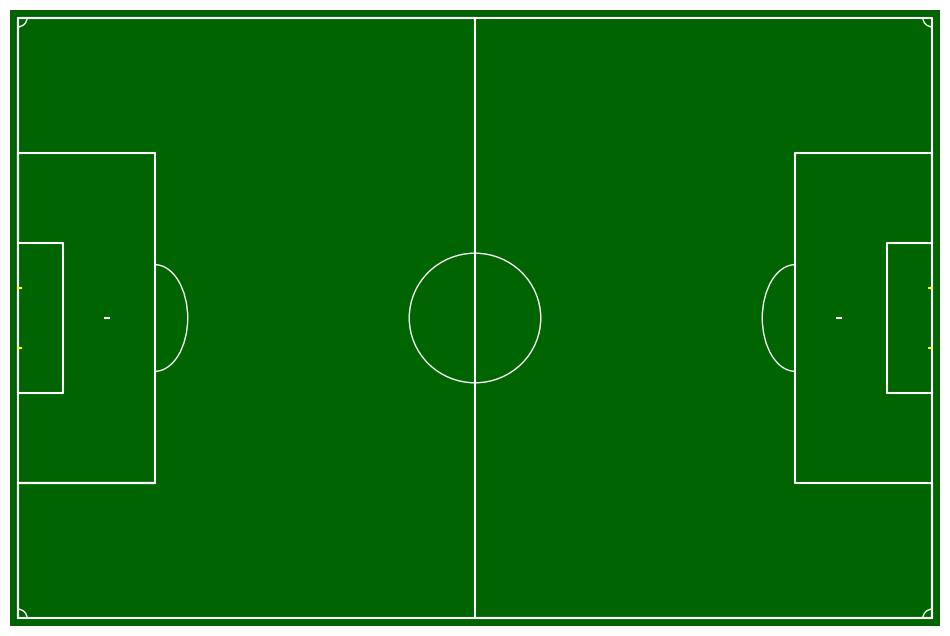

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Reference from "https://www.kaggle.com/code/ajsteele/draw-soccer-pitch-with-matplotlib"
def draw_soccer_pitch(figsize=(12, 8)):
    """
    Function that plots a scaled soccer pitch of length 120*80 to match with the data from statbomb
    """
    rect = patches.Rectangle((-1, -1), 122, 82, linewidth=0.1,
                             edgecolor='r', facecolor='darkgreen', zorder=0)

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.add_patch(rect)
    # Main pitch markings, ie sidelines, penalty area and halfway line
    plt.plot([0,0,0,120,120,0,0,18,0,18,18,0,0,6,6,0,0,60,60,120,120,102,102,120,120,114,114,120],
             [0,0,80,80,0,0,18,18,18,18,62,62,50,50,30,30,80,80,0,0, 18, 18, 62, 62, 50, 50, 30, 30], color='white')

    # Secondary pitch markings, ie penalty spots, centre circle etc
    plt.plot([12, 11.5],[40, 40], color='white')
    plt.plot([108, 107.5],[40, 40], color='white')
    
    centre_circle = patches.Circle([60, 40], 8.627, edgecolor='white', facecolor='darkgreen')
    ax.add_patch(centre_circle)
    
    left_arc = patches.Arc([18, 40], 8.627, 14.2, theta1=270.0, theta2=90.0, color='white')
    ax.add_patch(left_arc)
    right_arc = patches.Arc([102, 40], 8.627, 14.2, theta1=90.0, theta2=270.0, color='white')
    ax.add_patch(right_arc)
    
    bl_corner = patches.Arc([0, 0], 2.5, 2.5, theta1=0.0, theta2=90.0, color='white')
    tl_corner = patches.Arc([0, 80], 2.5, 2.5, theta1=270.0, color='white')
    br_corner = patches.Arc([120, 0], 2.5, 2.5, theta1=90.0, theta2=180.0, color='white')
    tr_corner = patches.Arc([120, 80], 2.5, 2.5, theta1=180.0, theta2=270.0,color='white')
    ax.add_patch(bl_corner)
    ax.add_patch(tl_corner)
    ax.add_patch(br_corner)
    ax.add_patch(tr_corner)

    # The goalkeeper:
    plt.plot([0, 0.5],[36, 36], color='yellow')
    plt.plot([0, 0.5],[44, 44], color='yellow')
    plt.plot([120, 119.5],[36, 36], color='yellow')
    plt.plot([120, 119.5],[44, 44], color='yellow')
    
    plt.xlim(-1, 121)
    plt.ylim(-1, 81)
    plt.axis('off')    

    return fig, ax

draw_soccer_pitch()
plt.show()

In [30]:
# 'player': {'id': 5537, 'name': 'Fabian Lukas Schär'} Let's extract everything this person do in this "3890561" match
# 'player': {'id': 6039, 'name': 'Sebastian Rudy'}

In [31]:
event_path = os.path.join(events_path, str(3890561) + '.json')
event_dict_list = json.load(open(event_path, 'r'))
event_dict_list[0]["tactics"]

{'formation': 3421,
 'lineup': [{'player': {'id': 37972, 'name': 'Jens Grahl'},
   'position': {'id': 1, 'name': 'Goalkeeper'},
   'jersey_number': 13},
  {'player': {'id': 5537, 'name': 'Fabian Lukas Schär'},
   'position': {'id': 3, 'name': 'Right Center Back'},
   'jersey_number': 5},
  {'player': {'id': 9396, 'name': 'Ermin Bičakčić'},
   'position': {'id': 4, 'name': 'Center Back'},
   'jersey_number': 4},
  {'player': {'id': 12321, 'name': 'Tobias Strobl'},
   'position': {'id': 5, 'name': 'Left Center Back'},
   'jersey_number': 12},
  {'player': {'id': 9397, 'name': 'Pavel Kadeřábek'},
   'position': {'id': 7, 'name': 'Right Wing Back'},
   'jersey_number': 3},
  {'player': {'id': 26832, 'name': 'Tarik Elyounoussi'},
   'position': {'id': 8, 'name': 'Left Wing Back'},
   'jersey_number': 14},
  {'player': {'id': 8556, 'name': 'Pirmin Schwegler'},
   'position': {'id': 9, 'name': 'Right Defensive Midfield'},
   'jersey_number': 16},
  {'player': {'id': 6039, 'name': 'Sebastian R

In [32]:
player_in_check =  {'id': 5460, 'name': 'Andrej Kramarić'}
event_involved = []
idx = 0
for event in event_dict_list:
    try:
        print(event["player"]["name"])
        if event["player"] == player_in_check:
            event_involved.append(event)
        idx += 1
    except KeyError:
        idx += 1


Mark Uth
Andrej Kramarić
Andrej Kramarić
Andrej Kramarić
Sebastian Rudy
Sebastian Rudy
Sebastian Rudy
Fabian Lukas Schär
Fabian Lukas Schär
Fabian Lukas Schär
Tobias Strobl
Tobias Strobl
Tobias Strobl
Ermin Bičakčić
Ermin Bičakčić
Ermin Bičakčić
Tobias Strobl
Tobias Strobl
Tobias Strobl
Leroy Sané
Tarik Elyounoussi
Tarik Elyounoussi
Tarik Elyounoussi
Andrej Kramarić
Andrej Kramarić
Benedikt Höwedes
Andrej Kramarić
Kevin Volland
Benedikt Höwedes
Joël Andre Job Matip
Joël Andre Job Matip
Joël Andre Job Matip
Roman Neustädter
Roman Neustädter
Roman Neustädter
Sead Kolašinac
Sead Kolašinac
Sead Kolašinac
Roman Neustädter
Roman Neustädter
Roman Neustädter
Joël Andre Job Matip
Joël Andre Job Matip
Kevin Volland
Joël Andre Job Matip
Ralf Fährmann
Ralf Fährmann
Mark Uth
Ralf Fährmann
Mark Uth
Johannes Geis
Johannes Geis
Pirmin Schwegler
Johannes Geis
Benedikt Höwedes
Benedikt Höwedes
Kevin Volland
Benedikt Höwedes
Leroy Sané
Leroy Sané
Leroy Sané
Roman Neustädter
Roman Neustädter
Roman Neustäd

In [33]:
len(event_involved)

148

In [34]:
x_coord_defensive = []
y_coord_defensive = []
x_coord_offensive = []
y_coord_offensive = []
x_coord_receive = []
y_coord_receive = []
x_coord_pass = []
y_coord_pass = []
y_coord_offensive = []
x_coord_foul = []
y_coord_foul = []
x_coord_lost = []  
y_coord_lost = []
x_coord_carry_start = []
y_coord_carry_start = []
x_coord_carry_end = []
y_coord_carry_end = []

event_type = []
defensive_event = ['Block','Interception','Clearance','Ball Recovery','Shield']
offensive_event = ['Pressure','Duel','Dribble','Shot', 'Offside', '50/50','Own Goal For']
foul_event = ['Own Goal Against','Foul Committed','Foul Won','Error']
ball_lost_event = ['Miscontrol', 'Dribble Past','Dispossessed']

for event in event_involved:
    if event["type"] not in event_type:
        event_type.append(event["type"])
    if event["type"]["name"] in  offensive_event:
        x_coord_offensive.append(event["location"][0])
        y_coord_offensive.append(event["location"][1])
    if event["type"]["name"] in  defensive_event:
        x_coord_defensive.append(event["location"][0])
        y_coord_defensive.append(event["location"][1])
    if event["type"]["name"] in  foul_event:
        x_coord_foul.append(event["location"][0])
        y_coord_foul.append(event["location"][1])
    if event["type"]["name"] in  ball_lost_event:
        x_coord_lost.append(event["location"][0])
        y_coord_lost.append(event["location"][1])
    if event["type"]["name"] == 'Pass':
        x_coord_pass.append(event["location"][0])
        y_coord_pass.append(event["location"][1])
    if event["type"]["name"] == 'Ball Receipt*':
        x_coord_receive.append(event["location"][0])
        y_coord_receive.append(event["location"][1])
    if event["type"]["name"] == 'Carry':
        x_coord_carry_start.append(event["location"][0]) 
        y_coord_carry_start.append(event["location"][1])
        x_coord_carry_end.append(event["carry"]["end_location"][0]) 
        y_coord_carry_end.append(event["carry"]["end_location"][1])


/tmp/ipykernel_3972/695766140.py:1: DeprecationWarning: Please use `gaussian_kde` from the `scipy.stats` namespace, the `scipy.stats.kde` namespace is deprecated.
  from scipy.stats.kde import gaussian_kde


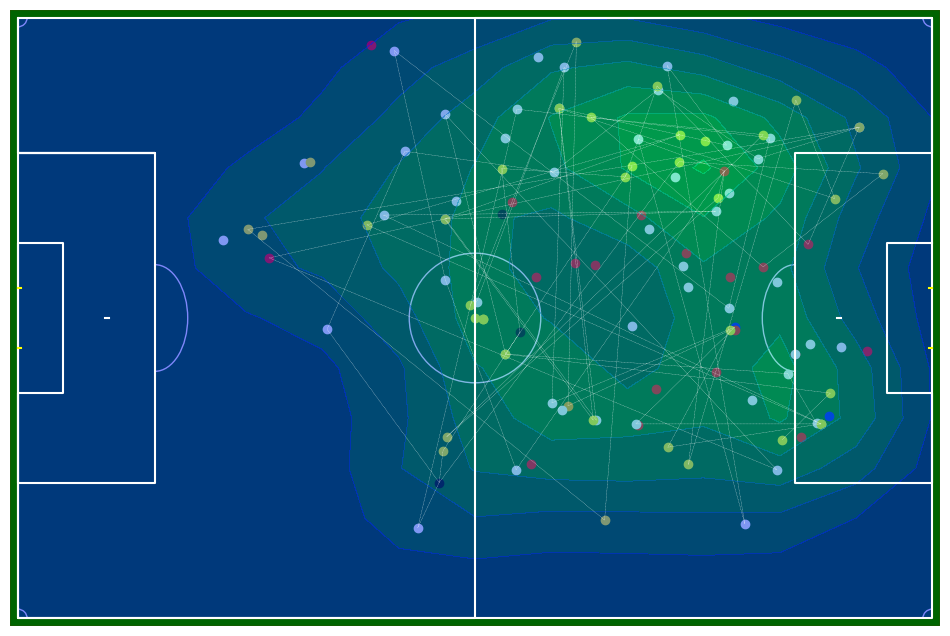

In [35]:
from scipy.stats.kde import gaussian_kde

draw_soccer_pitch()
plt.grid(False)   
ax=plt.gca()                            # get the axis
ax.set_ylim(ax.get_ylim()[::-1])        # invert the axis
ax.xaxis.tick_top()                     # and move the X-Axis      
ax.yaxis.tick_left()

x = np.array(x_coord_defensive + x_coord_offensive + x_coord_foul + x_coord_lost + x_coord_carry_start + x_coord_carry_end + x_coord_receive + x_coord_pass)
y = np.array(y_coord_defensive + y_coord_offensive + y_coord_foul + y_coord_lost + y_coord_carry_start + y_coord_carry_end + y_coord_receive + y_coord_pass)
k = gaussian_kde(np.vstack([x, y]))
xi, yi = np.mgrid[0:120:x.size**0.5*1j,0:80:y.size**0.5*1j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))

plt.scatter(x_coord_defensive, y_coord_defensive, color="blue")
plt.scatter(x_coord_offensive, y_coord_offensive,color="red")
plt.scatter(x_coord_foul, y_coord_foul, color="black")
plt.scatter(x_coord_lost, y_coord_lost, color="orange")
plt.scatter(x_coord_receive, y_coord_receive, color="white")
plt.scatter(x_coord_pass, y_coord_pass, color="yellow")
plt.plot(x_coord_carry_start, y_coord_carry_start,x_coord_carry_end,y_coord_carry_end, color="white", ls ='--',linewidth=0.2)
plt.contourf(xi, yi, zi.reshape(xi.shape), alpha=0.5, cmap=plt.get_cmap('winter'))
plt.show()

In [36]:
matches_df

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,meta_data,match_week,competition_stage,stadium,referee
0,3890561,2016-05-14,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 175, 'home_team_name': 'Hoffe...","{'away_team_id': 181, 'away_team_name': 'Schal...",1,4,available,unscheduled,2023-07-24T07:47:12.510532,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",34,"{'id': 1, 'name': 'Regular Season'}","{'id': 4541, 'name': 'PreZero Arena', 'country...","{'id': 186, 'name': 'Felix Brych', 'country': ..."
1,3890505,2016-04-02,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 169, 'home_team_name': 'Bayer...","{'away_team_id': 184, 'away_team_name': 'Eintr...",1,0,available,unscheduled,2023-08-03T13:14:14.503553,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 4867, 'name': 'Allianz Arena', 'country...","{'id': 1008758, 'name': 'Florian Meyer', 'coun..."
2,3890511,2016-04-08,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 178, 'away_team_name': 'Hanno...",2,2,available,unscheduled,2023-08-06T05:50:38.345688,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 235, 'name': 'Benjamin Brand', 'country..."
3,3890515,2016-04-09,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 171, 'home_team_name': 'Hambu...","{'away_team_id': 872, 'away_team_name': 'Darms...",1,2,available,unscheduled,2023-07-18T17:52:17.363623,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 379, 'name': 'Volksparkstadion', 'count...","{'id': 1008767, 'name': 'Peter Sippel', 'count..."
4,3890411,2015-12-20,16:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 177, 'away_team_name': 'FSV M...",2,0,available,unscheduled,2023-07-16T13:47:06.565811,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",17,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 1008767, 'name': 'Peter Sippel', 'count..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3194,69199,2019-06-27,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 852, 'home_team_name': 'Norwa...","{'away_team_id': 865, 'away_team_name': 'Engla...",0,3,available,scheduled,2023-07-24T21:48:06.945119,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",5,"{'id': 1, 'name': 'Regular Season'}","{'id': 230, 'name': 'Stade Océane', 'country':...","{'id': 1638, 'name': 'Lucila Venegas Montes', ..."
3195,69258,2019-07-02,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 865, 'home_team_name': 'Engla...","{'away_team_id': 1214, 'away_team_name': 'Unit...",1,2,available,scheduled,2023-07-27T10:32:52.092920,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",6,"{'id': 15, 'name': 'Semi-finals'}","{'id': 193, 'name': 'Groupama Stadium', 'count...",NaN
3196,69284,2019-07-03,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 851, 'home_team_name': 'Nethe...","{'away_team_id': 858, 'away_team_name': 'Swede...",1,0,available,scheduled,2023-07-24T21:53:19.994655,2021-06-

In [37]:
#Activity frame:
refine_players_df["player_name"][10]

'Nabil Fekir'

In [38]:
matches_df["competition"]

0       {'competition_id': 9, 'country_name': 'Germany...
1       {'competition_id': 9, 'country_name': 'Germany...
2       {'competition_id': 9, 'country_name': 'Germany...
3       {'competition_id': 9, 'country_name': 'Germany...
4       {'competition_id': 9, 'country_name': 'Germany...
                              ...                        
3194    {'competition_id': 72, 'country_name': 'Intern...
3195    {'competition_id': 72, 'country_name': 'Intern...
3196    {'competition_id': 72, 'country_name': 'Intern...
3197    {'competition_id': 72, 'country_name': 'Intern...
3198    {'competition_id': 72, 'country_name': 'Intern...
Name: competition, Length: 3199, dtype: object

In [39]:
matches_df["season_id"] = [x['season_id'] for x in matches_df["season"]]
matches_df["competition_id"] = [x['competition_id'] for x in matches_df["competition"]]
matches_df

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,meta_data,match_week,competition_stage,stadium,referee,season_id,competition_id
0,3890561,2016-05-14,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 175, 'home_team_name': 'Hoffe...","{'away_team_id': 181, 'away_team_name': 'Schal...",1,4,available,unscheduled,2023-07-24T07:47:12.510532,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",34,"{'id': 1, 'name': 'Regular Season'}","{'id': 4541, 'name': 'PreZero Arena', 'country...","{'id': 186, 'name': 'Felix Brych', 'country': ...",27,9
1,3890505,2016-04-02,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 169, 'home_team_name': 'Bayer...","{'away_team_id': 184, 'away_team_name': 'Eintr...",1,0,available,unscheduled,2023-08-03T13:14:14.503553,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 4867, 'name': 'Allianz Arena', 'country...","{'id': 1008758, 'name': 'Florian Meyer', 'coun...",27,9
2,3890511,2016-04-08,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 178, 'away_team_name': 'Hanno...",2,2,available,unscheduled,2023-08-06T05:50:38.345688,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 235, 'name': 'Benjamin Brand', 'country...",27,9
3,3890515,2016-04-09,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 171, 'home_team_name': 'Hambu...","{'away_team_id': 872, 'away_team_name': 'Darms...",1,2,available,unscheduled,2023-07-18T17:52:17.363623,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 379, 'name': 'Volksparkstadion', 'count...","{'id': 1008767, 'name': 'Peter Sippel', 'count...",27,9
4,3890411,2015-12-20,16:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 177, 'away_team_name': 'FSV M...",2,0,available,unscheduled,2023-07-16T13:47:06.565811,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",17,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 1008767, 'name': 'Peter Sippel', 'count...",27,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3194,69199,2019-06-27,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 852, 'home_team_name': 'Norwa...","{'away_team_id': 865, 'away_team_name': 'Engla...",0,3,available,scheduled,2023-07-24T21:48:06.945119,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",5,"{'id': 1, 'name': 'Regular Season'}","{'id': 230, 'name': 'Stade Océane', 'country':...","{'id': 1638, 'name': 'Lucila Venegas Montes', ...",30,72
3195,69258,2019-07-02,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 865, 'home_team_name': 'Engla...","{'away_team_id': 1214, 'away_team_name': 'Unit...",1,2,available,scheduled,2023-07-27T10:32:52.092920,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",6,"{'id': 15, 'name': 'Semi-finals'}","{'id': 193, 'name': 'Groupama Stadium', 'count...",NaN,30,72
3196,69284,2019-07-03,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 851, 'home_team_name': 'Nethe...","{'away_team_id': 858, 'away_team_name': 

In [16]:
def report_player_available():
    player = input("Enter the player name for heatmap: ")
    player_available_in = refine_players_df[refine_players_df["player_name"] == player]
    player_season_id =  [x["season_id"] for x in player_available_in["season_id"]]
    player_competition_id = [x["competition_id"] for x in player_available_in["competition_id"]]

    player_match_id = []
    for i in range(len(player_season_id)):
        match_id_df = matches_df[(matches_df["competition_id"] == player_competition_id[i]) & (matches_df["season_id"] == player_season_id[i])]
        match_id = match_id_df["match_id"].tolist()
        player_match_id += match_id
    
    
    # Search further whether the player is in this match_id
    refine_player_match_id = []
    for id in player_match_id: 
        lineup_path = os.path.join(lineups_path, str(id) + '.json')
        lineup_dict = json.load(open(lineup_path, 'r'))
        for team_lineup in lineup_dict:
            for players in team_lineup["lineup"]:
                if players["player_name"] == player:
                    refine_player_match_id.append(id)
        
    print(refine_player_match_id)
    match = input("Pick a match for heatmap: ")
    match_to_str = str(match)
    event_path = os.path.join(events_path, match_to_str + '.json')
    event_dict_list = json.load(open(event_path, 'r'))

    #If only 1 match is needed
    event_involved = []
    for event in event_dict_list:
        try:
            if event["player"]["name"] == player:
                event_involved.append(event)
        except KeyError:
            continue
    
    x_coord_defensive = []
    y_coord_defensive = []
    x_coord_offensive = []
    y_coord_offensive = []
    x_coord_receive = []
    y_coord_receive = []
    x_coord_pass = []
    y_coord_pass = []
    y_coord_offensive = []
    x_coord_foul = []
    y_coord_foul = []
    x_coord_lost = []  
    y_coord_lost = []
    x_coord_carry_start = []
    y_coord_carry_start = []
    x_coord_carry_end = []
    y_coord_carry_end = []

    event_type = []
    defensive_event = ['Block','Interception','Clearance','Ball Recovery','Shield']
    offensive_event = ['Pressure','Duel','Dribble','Shot', 'Offside', '50/50','Own Goal For']
    foul_event = ['Own Goal Against','Foul Committed','Foul Won','Error']
    ball_lost_event = ['Miscontrol', 'Dribble Past','Dispossessed']

    for event in event_involved:
        if event["type"] not in event_type:
            event_type.append(event["type"])
        if event["type"]["name"] in  offensive_event:
            x_coord_offensive.append(event["location"][0])
            y_coord_offensive.append(event["location"][1])
        if event["type"]["name"] in  defensive_event:
            x_coord_defensive.append(event["location"][0])
            y_coord_defensive.append(event["location"][1])
        if event["type"]["name"] in  foul_event:
            x_coord_foul.append(event["location"][0])
            y_coord_foul.append(event["location"][1])
        if event["type"]["name"] in  ball_lost_event:
            x_coord_lost.append(event["location"][0])
            y_coord_lost.append(event["location"][1])
        if event["type"]["name"] == 'Pass':
            x_coord_pass.append(event["location"][0])
            y_coord_pass.append(event["location"][1])
        if event["type"]["name"] == 'Ball Receipt*':
            x_coord_receive.append(event["location"][0])
            y_coord_receive.append(event["location"][1])
        if event["type"]["name"] == 'Carry':
            x_coord_carry_start.append(event["location"][0]) 
            y_coord_carry_start.append(event["location"][1])
            x_coord_carry_end.append(event["carry"]["end_location"][0]) 
            y_coord_carry_end.append(event["carry"]["end_location"][1])
    
    draw_soccer_pitch()
    plt.grid(False)   
    ax=plt.gca()                            # get the axis
    ax.set_ylim(ax.get_ylim()[::-1])        # invert the axis
    ax.xaxis.tick_top()                     # and move the X-Axis      
    ax.yaxis.tick_left()

    x = np.array(x_coord_defensive + x_coord_offensive + x_coord_foul + x_coord_lost + x_coord_carry_start + x_coord_carry_end + x_coord_receive + x_coord_pass)
    y = np.array(y_coord_defensive + y_coord_offensive + y_coord_foul + y_coord_lost + y_coord_carry_start + y_coord_carry_end + y_coord_receive + y_coord_pass)
    k = gaussian_kde(np.vstack([x, y]))
    xi, yi = np.mgrid[0:120:x.size**0.5*1j,0:80:y.size**0.5*1j]
    zi = k(np.vstack([xi.flatten(), yi.flatten()]))

    plt.scatter(x_coord_defensive, y_coord_defensive, color="blue")
    plt.scatter(x_coord_offensive, y_coord_offensive,color="red")
    plt.scatter(x_coord_foul, y_coord_foul, color="black")
    plt.scatter(x_coord_lost, y_coord_lost, color="orange")
    plt.scatter(x_coord_receive, y_coord_receive, color="white")
    plt.scatter(x_coord_pass, y_coord_pass, color="yellow")
    plt.plot(x_coord_carry_start, y_coord_carry_start,x_coord_carry_end,y_coord_carry_end, color="white", ls ='--',linewidth=0.2)
    plt.contourf(xi, yi, zi.reshape(xi.shape), alpha=0.5, cmap=plt.get_cmap('winter'))
    plt.show()

report_player_available()


NameError: name 'refine_players_df' is not defined

In [41]:
def pass_map(match_id):
    print("hello")

In [15]:
import networkx as nx
match_id = 3890561
event_path = os.path.join(events_path, str(match_id) + '.json')
event_dict_list = json.load(open(event_path, 'r'))
lineup_path = os.path.join(lineups_path, str(match_id) + '.json')
lineup_dict = json.load(open(lineup_path, 'r'))

home_team = matches_df[matches_df['match_id'] == match_id]['home_team'][0]['home_team_name']
away_team = matches_df[matches_df['match_id'] == match_id]['away_team'][0]['away_team_name']

pass_events_home = []
pass_events_away = []
for event in event_dict_list:
    if event["type"]["name"] == "Pass":
        if event["team"]["name"] == home_team:
            pass_events_home.append(event)
        elif event["team"]["name"] == away_team:
            pass_events_away.append(event)


home_player_dict = dict({})
away_player_dict = dict({})
home_edge_counters = dict({})
away_edge_counters = dict({})

idx = 0

for pass_event in pass_events_home:
    id_passer = pass_event["player"]["id"]
    location_passer = pass_event["location"]
    if str(id_passer) in home_player_dict.keys():
        old_location = home_player_dict[str(id_passer)]["location"]
        old_freq = home_player_dict[str(id_passer)]["freq"]
        new_x = (old_location[0]*old_freq + location_passer[0])/(old_freq + 1)
        new_y = (old_location[1]*old_freq + location_passer[1])/(old_freq + 1)
        home_player_dict[str(id_passer)]["location"] = [new_x,new_y]
        home_player_dict[str(id_passer)]["freq"] = old_freq + 1
    else:
        home_player_dict[str(id_passer)] = {}
        home_player_dict[str(id_passer)]["location"] = location_passer
        home_player_dict[str(id_passer)]["freq"] = 1
    try:
        id_receiever = pass_event["pass"]["recipient"]["id"]
        location_receiver = pass_event["pass"]["end_location"]
        if str(id_receiever) in home_player_dict.keys():
            old_location = home_player_dict[str(id_receiever)]["location"]
            old_freq = home_player_dict[str(id_receiever)]["freq"]
            new_x = (old_location[0]*old_freq + location_receiver[0])/(old_freq + 1)
            new_y = (old_location[1]*old_freq + location_receiver[1])/(old_freq + 1)
            home_player_dict[str(id_receiever)]["location"] = [new_x,new_y]
            home_player_dict[str(id_receiever)]["freq"] = old_freq + 1
        else:
            home_player_dict[str(id_receiever)] = {}
            home_player_dict[str(id_receiever)]["location"] = location_receiver
            home_player_dict[str(id_receiever)]["freq"] = 1

        # Update the edge:
        if str(id_passer) + "/" + str(id_receiever) in home_edge_counters.keys():
            home_edge_counters[str(id_passer) + "/" + str(id_receiever)] += 1
        else:
            home_edge_counters[str(id_passer) + "/" + str(id_receiever)] = 1

    except KeyError:
        continue


for pass_event in pass_events_away:
    id_passer = pass_event["player"]["id"]
    location_passer = pass_event["location"]
    if str(id_passer) in away_player_dict.keys():
        old_location = away_player_dict[str(id_passer)]["location"]
        old_freq = away_player_dict[str(id_passer)]["freq"]
        new_x = (old_location[0]*old_freq + location_passer[0])/(old_freq + 1)
        new_y = (old_location[1]*old_freq + location_passer[1])/(old_freq + 1)
        away_player_dict[str(id_passer)]["location"] = [new_x,new_y]
        away_player_dict[str(id_passer)]["freq"] = old_freq + 1
    else:
        away_player_dict[str(id_passer)] = {}
        away_player_dict[str(id_passer)]["location"] = location_passer
        away_player_dict[str(id_passer)]["freq"] = 1
    try:
        id_receiever = pass_event["pass"]["recipient"]["id"]
        location_receiver = pass_event["pass"]["end_location"]
        if str(id_receiever) in away_player_dict.keys():
            old_location = away_player_dict[str(id_receiever)]["location"]
            old_freq = away_player_dict[str(id_receiever)]["freq"]
            new_x = (old_location[0]*old_freq + location_receiver[0])/(old_freq + 1)
            new_y = (old_location[1]*old_freq + location_receiver[1])/(old_freq + 1)
            away_player_dict[str(id_receiever)]["location"] = [new_x,new_y]
            away_player_dict[str(id_receiever)]["freq"] = old_freq + 1
        else:
            away_player_dict[str(id_receiever)] = {}
            away_player_dict[str(id_receiever)]["location"] = location_receiver
            away_player_dict[str(id_receiever)]["freq"] = 1
            
        if str(id_passer) + "/" + str(id_receiever) in away_edge_counters.keys():
            away_edge_counters[str(id_passer) + "/" + str(id_receiever)] += 1
        else:
            away_edge_counters[str(id_passer) + "/" + str(id_receiever)] = 1
    except KeyError:
        continue

#print(len(pass_events_home))
#print(len(pass_events_away))

NameError: name 'matches_df' is not defined

In [111]:
lineup_path = os.path.join(lineups_path, str(match_id) + '.json')
lineup_dict = json.load(open(lineup_path, 'r'))
team_1 = [x["player_id"] for x in lineup_dict[0]["lineup"]]

In [112]:
team_1_check = 0
team_2_check = 0
for x in home_player_dict.keys():
    if int(x) in team_1:
        team_1_check = team_1_check + 1
    else:
        team_2_check = team_2_check + 1

print(team_1_check)
print(team_2_check)

0
14


In [113]:
team_1_check = 0
team_2_check = 0
for x in away_player_dict.keys():
    if int(x) in team_1:
        team_1_check = team_1_check + 1
    else:
        team_2_check = team_2_check + 1

print(team_1_check)
print(team_2_check)

13
0


In [116]:
home_edge_counters

{'8387/5460': 4,
 '5460/6039': 5,
 '6039/5537': 7,
 '5537/12321': 4,
 '12321/9396': 11,
 '9396/12321': 8,
 '12321/26832': 7,
 '26832/5460': 6,
 '5460/8215': 5,
 '5537/8387': 8,
 '8387/8215': 1,
 '9396/8387': 2,
 '8387/9397': 3,
 '5537/9396': 11,
 '12321/6039': 5,
 '6039/12321': 3,
 '9396/6039': 1,
 '5537/8215': 4,
 '8215/8387': 6,
 '8556/5537': 10,
 '5537/26832': 8,
 '6039/8215': 4,
 '5460/9397': 3,
 '9397/5460': 3,
 '5460/26832': 7,
 '26832/12321': 9,
 '9396/5537': 13,
 '5537/8556': 6,
 '8556/12321': 7,
 '12321/5537': 5,
 '8387/8556': 2,
 '8556/9397': 3,
 '9397/26832': 3,
 '8215/26832': 3,
 '26832/8387': 3,
 '5460/5537': 3,
 '5537/6039': 8,
 '9397/8387': 4,
 '9397/6039': 5,
 '6039/5460': 9,
 '9396/9397': 2,
 '9397/5537': 9,
 '5537/37972': 2,
 '37972/9396': 4,
 '9396/5460': 5,
 '5460/12321': 2,
 '9396/8556': 8,
 '6039/9397': 4,
 '6039/26832': 11,
 '26832/6039': 8,
 '5537/9397': 13,
 '9397/8556': 4,
 '37972/12321': 2,
 '12321/8556': 5,
 '26832/8556': 2,
 '9397/37972': 3,
 '37972/8215': 

In [46]:
len(home_player_dict)

22

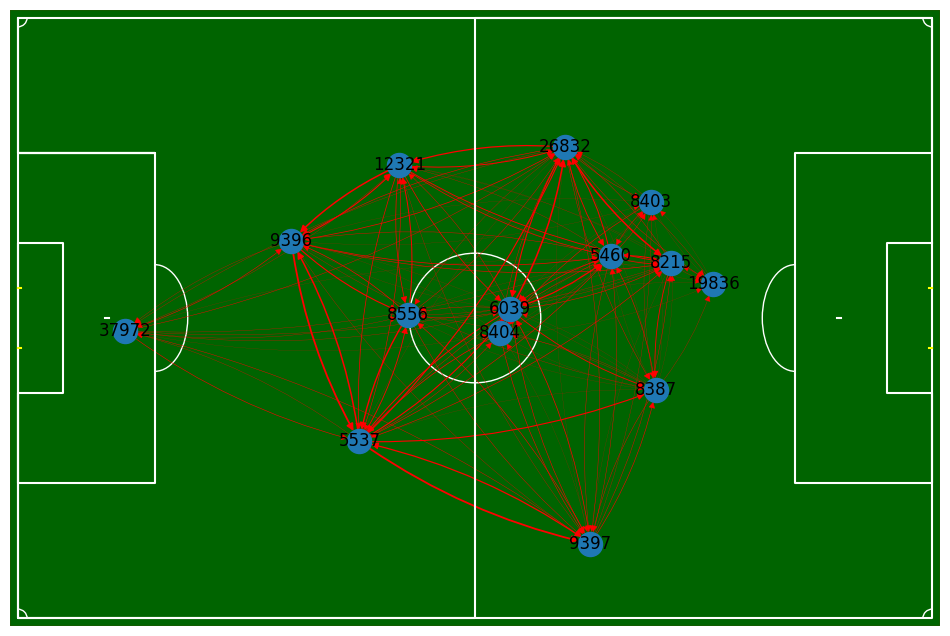

In [168]:
import networkx as nx
import matplotlib.pyplot as plt

# test home_player_dict; home_edge_counters
G = nx.DiGraph()
home_key = list(home_player_dict.keys())
touch_ball = [x["freq"] for x in list(home_player_dict.values())]
home_edge_key = list(home_edge_counters.keys())

for i in range(len(home_player_dict)):
    node = home_key[i]
    x_coord = home_player_dict[node]["location"][0]
    y_coord = home_player_dict[node]["location"][1]
    G.add_node(node, pos = (x_coord, y_coord))


for j in range(len(home_edge_counters)):
    node_1 = home_edge_key[j].split('/')[0]
    node_2 = home_edge_key[j].split('/')[1]
    occurence = home_edge_counters[home_edge_key[j]]
    G.add_edge(node_1,node_2, weight = occurence)

draw_soccer_pitch()
plt.grid(False)   
ax=plt.gca()                            # get the axis
ax.set_ylim(ax.get_ylim()[::-1])        # invert the axis
ax.xaxis.tick_top()                     # and move the X-Axis      
ax.yaxis.tick_left()

pos = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G,pos)
for edge in G.edges(data='weight'):
    nx.draw_networkx_edges(G, pos, edgelist=[edge], width=edge[2]*0.1, connectionstyle='arc3, rad = 0.1', edge_color='red')


In [155]:
G.edges(data='weight')

OutEdgeDataView([('8387', '5460', 4), ('8387', '8215', 1), ('8387', '9397', 3), ('8387', '8556', 2), ('8387', '19836', 2), ('8387', '5537', 1), ('8387', '6039', 1), ('8387', '26832', 1), ('8387', '8404', 2), ('8387', '8403', 1), ('8387', '9396', 1), ('5460', '6039', 5), ('5460', '8215', 5), ('5460', '9397', 3), ('5460', '26832', 7), ('5460', '5537', 3), ('5460', '12321', 2), ('5460', '9396', 3), ('5460', '8387', 1), ('5460', '8403', 3), ('5460', '8404', 1), ('6039', '5537', 7), ('6039', '12321', 3), ('6039', '8215', 4), ('6039', '5460', 9), ('6039', '9397', 4), ('6039', '26832', 11), ('6039', '8387', 6), ('6039', '8556', 3), ('6039', '8404', 2), ('6039', '8403', 1), ('5537', '12321', 4), ('5537', '8387', 8), ('5537', '9396', 11), ('5537', '8215', 4), ('5537', '26832', 8), ('5537', '8556', 6), ('5537', '6039', 8), ('5537', '37972', 2), ('5537', '9397', 13), ('5537', '5460', 4), ('5537', '8404', 3), ('12321', '9396', 11), ('12321', '26832', 7), ('12321', '6039', 5), ('12321', '5537', 5),

In [152]:
curved_edges

[('8387', '5460'),
 ('8387', '8215'),
 ('8387', '9397'),
 ('8387', '8556'),
 ('8387', '5537'),
 ('8387', '6039'),
 ('8387', '26832'),
 ('8387', '8404'),
 ('8387', '8403'),
 ('8387', '9396'),
 ('5460', '6039'),
 ('5460', '8215'),
 ('5460', '9397'),
 ('5460', '26832'),
 ('5460', '5537'),
 ('5460', '12321'),
 ('5460', '9396'),
 ('5460', '8387'),
 ('5460', '8403'),
 ('5460', '8404'),
 ('6039', '5537'),
 ('6039', '12321'),
 ('6039', '8215'),
 ('6039', '5460'),
 ('6039', '9397'),
 ('6039', '26832'),
 ('6039', '8387'),
 ('6039', '8556'),
 ('6039', '8404'),
 ('6039', '8403'),
 ('5537', '12321'),
 ('5537', '8387'),
 ('5537', '9396'),
 ('5537', '26832'),
 ('5537', '8556'),
 ('5537', '6039'),
 ('5537', '37972'),
 ('5537', '9397'),
 ('5537', '5460'),
 ('5537', '8404'),
 ('12321', '9396'),
 ('12321', '26832'),
 ('12321', '6039'),
 ('12321', '5537'),
 ('12321', '8556'),
 ('12321', '5460'),
 ('12321', '8215'),
 ('12321', '19836'),
 ('9396', '12321'),
 ('9396', '8387'),
 ('9396', '5537'),
 ('9396', '5

In [143]:
set(home_edge_counters.keys())

{'12321/19836',
 '12321/26832',
 '12321/5460',
 '12321/5537',
 '12321/6039',
 '12321/8215',
 '12321/8556',
 '12321/9396',
 '12321/9397',
 '19836/12321',
 '19836/26832',
 '19836/6039',
 '19836/8215',
 '19836/8403',
 '26832/12321',
 '26832/19836',
 '26832/37972',
 '26832/5460',
 '26832/5537',
 '26832/6039',
 '26832/8215',
 '26832/8387',
 '26832/8403',
 '26832/8404',
 '26832/8556',
 '26832/9396',
 '26832/9397',
 '37972/12321',
 '37972/26832',
 '37972/5460',
 '37972/5537',
 '37972/6039',
 '37972/8215',
 '37972/8404',
 '37972/8556',
 '37972/9396',
 '5460/12321',
 '5460/26832',
 '5460/5537',
 '5460/6039',
 '5460/8215',
 '5460/8387',
 '5460/8403',
 '5460/8404',
 '5460/9396',
 '5460/9397',
 '5537/12321',
 '5537/26832',
 '5537/37972',
 '5537/5460',
 '5537/6039',
 '5537/8215',
 '5537/8387',
 '5537/8404',
 '5537/8556',
 '5537/9396',
 '5537/9397',
 '6039/12321',
 '6039/26832',
 '6039/5460',
 '6039/5537',
 '6039/8215',
 '6039/8387',
 '6039/8403',
 '6039/8404',
 '6039/8556',
 '6039/9397',
 '8215/123

In [109]:
from matplotlib.ticker import MultipleLocator

def player_heatmap(match_id, player_name):

    match_to_str = str(match_id)
    event_path = os.path.join(events_path, match_to_str + '.json')
    event_dict_list = json.load(open(event_path, 'r'))

    #If only 1 match is needed
    event_involved = []
    for event in event_dict_list:
        try:
            if event["player"]["name"] == player_name:
                event_involved.append(event)
        except KeyError:
            continue
    
    x_coord_defensive = []
    y_coord_defensive = []
    duration_defensive = []

    x_coord_offensive = []
    y_coord_offensive = []
    duration_offensive = []

    x_coord_receive = []
    y_coord_receive = []
    duration_receive = []

    x_coord_pass = []
    y_coord_pass = []
    duration_pass = []
    
    x_coord_foul = []
    y_coord_foul = []
    duration_foul = []

    x_coord_lost = []  
    y_coord_lost = []
    duration_lost = []

    x_coord_carry_start = []
    y_coord_carry_start = []
    duration_carry_start = []

    x_coord_carry_end = []
    y_coord_carry_end = []
    duration_carry_end = []

    event_type = []
    defensive_event = ['Block','Interception','Clearance','Ball Recovery','Shield']
    offensive_event = ['Pressure','Duel','Dribble','Shot', 'Offside', '50/50','Own Goal For']
    foul_event = ['Own Goal Against','Foul Committed','Foul Won','Error']
    ball_lost_event = ['Miscontrol', 'Dribble Past','Dispossessed']

    for event in event_involved:
        if event["type"] not in event_type:
            event_type.append(event["type"])

        if event["type"]["name"] in  offensive_event:
            x_coord_offensive.append(event["location"][0])
            y_coord_offensive.append(event["location"][1])
            try:
                duration_offensive.append(event["duration"])
            except KeyError:
                duration_offensive.append(1)
                continue
                
                                            
        if event["type"]["name"] in  defensive_event:
            x_coord_defensive.append(event["location"][0])
            y_coord_defensive.append(event["location"][1])
            try:
                duration_defensive.append(event["duration"])
            except KeyError:
                duration_defensive.append(1)
                continue

        if event["type"]["name"] in  foul_event:
            x_coord_foul.append(event["location"][0])
            y_coord_foul.append(event["location"][1])
            try:
                duration_foul.append(event["duration"])
            except KeyError:
                duration_foul.append(1)
                continue

        if event["type"]["name"] in  ball_lost_event:
            x_coord_lost.append(event["location"][0])
            y_coord_lost.append(event["location"][1])
            try:
                duration_lost.append(event["duration"])
            except KeyError:
                duration_lost.append(1)
                continue

        if event["type"]["name"] == 'Pass':
            x_coord_pass.append(event["location"][0])
            y_coord_pass.append(event["location"][1])
            try:
                duration_pass.append(event["duration"])
            except KeyError:
                duration_pass.append(1)
                continue

        if event["type"]["name"] == 'Ball Receipt*':
            x_coord_receive.append(event["location"][0])
            y_coord_receive.append(event["location"][1])
            try:
                duration_receive.append(event["duration"])
            except KeyError:
                duration_receive.append(1)
                continue

        if event["type"]["name"] == 'Carry':
            x_coord_carry_start.append(event["location"][0]) 
            y_coord_carry_start.append(event["location"][1])
            x_coord_carry_end.append(event["carry"]["end_location"][0]) 
            y_coord_carry_end.append(event["carry"]["end_location"][1])
            try:
                duration_carry_start.append(event["duration"]/2)
            except KeyError:
                duration_carry_start.append(1)
                continue
            try:
                duration_carry_end.append(event["duration"]/2)
            except KeyError:
                duration_carry_end.append(1)
                continue
    
    draw_soccer_pitch()
    plt.grid(False)   
    ax=plt.gca()                            # get the axis
    ax.set_ylim(ax.get_ylim()[::-1])        # invert the axis
    ax.xaxis.tick_top()                     # and move the X-Axis      
    ax.yaxis.tick_left()

    x = np.array(x_coord_defensive + x_coord_offensive + x_coord_foul + x_coord_lost + x_coord_carry_start + x_coord_carry_end + x_coord_receive + x_coord_pass)
    y = np.array(y_coord_defensive + y_coord_offensive + y_coord_foul + y_coord_lost + y_coord_carry_start + y_coord_carry_end + y_coord_receive + y_coord_pass)
    duration = (duration_defensive + duration_offensive + duration_foul + duration_lost + duration_carry_start + duration_carry_end + duration_receive + duration_pass)
    grid_label = []
    for i in range(len(x)):
        if (0 <= x[i] < 40) and (0 <= y[i] < 80/3):
            grid_label.append(1)
        elif (40 <= x[i] < 80) and (0 <= y[i] < 80/3):
            grid_label.append(2)
        elif (80 <= x[i] < 120) and (0 <= y[i] < 80/3):
            grid_label.append(3)
        elif (0 <= x[i] < 40) and (80/3 <= y[i] < 80*2/3):
            grid_label.append(4)
        elif (40 <= x[i] < 80) and (80/3 <= y[i] < 80*2/3):
            grid_label.append(5)
        elif (80 <= x[i] < 120) and (80/3 <= y[i] < 80*2/3):
            grid_label.append(6)
        elif (0 <= x[i] < 40) and (80*2/3 <= y[i] < 80):
            grid_label.append(7)
        elif (40 <= x[i] < 80) and (80*2/3 <= y[i] < 80):
            grid_label.append(8)
        elif (80 <= x[i] < 120) and (80*2/3 <= y[i] < 80):
            grid_label.append(9)
    
    # Calculate the final paercentages based on the duration: Output 9 dim
    weight = np.zeros(9)

    for i in range(len(grid_label)):
        lbl = grid_label[i] - 1
        weight[lbl] += duration[i]

    total_duration = weight.sum()
    display_weight = np.round(weight/total_duration*100, decimals = 1)

    k = gaussian_kde(np.vstack([x, y]))
    xi, yi = np.mgrid[0:120:x.size**0.5*1j,0:80:y.size**0.5*1j]
    zi = k(np.vstack([xi.flatten(), yi.flatten()]))
    plt.scatter(x_coord_defensive, y_coord_defensive, color="blue")
    plt.scatter(x_coord_offensive, y_coord_offensive,color="red")
    plt.scatter(x_coord_foul, y_coord_foul, color="black")
    plt.scatter(x_coord_lost, y_coord_lost, color="orange")
    plt.scatter(x_coord_receive, y_coord_receive, color="white")
    plt.scatter(x_coord_pass, y_coord_pass, color="yellow")
    plt.plot(x_coord_carry_start, y_coord_carry_start,x_coord_carry_end,y_coord_carry_end, color="white", ls ='--',linewidth=0.2)
    plt.contourf(xi, yi, zi.reshape(xi.shape), alpha=0.5, cmap=plt.get_cmap('winter'))
    
    #ax.set(xticks=range(0, 121, 40), yticks=range(0, 81, 27))

    for loc in range(0, 121, 40):
        ax.axvline(loc, alpha=0.2, color='black', linestyle='-', linewidth=2)

    for loc in range(0, 81, 27):
        ax.axhline(loc, alpha=0.2, color='black', linestyle='-', linewidth=2)

    plt.text(20,80/6, str(display_weight[0])+"%", fontsize = 20,ha='center', va='center')
    plt.text(60,80/6, str(display_weight[1])+"%", fontsize = 20,ha='center', va='center')
    plt.text(100,80/6, str(display_weight[2])+"%", fontsize = 20,ha='center', va='center')
    plt.text(20,40, str(display_weight[3])+"%", fontsize = 20,ha='center', va='center')
    plt.text(60,40, str(display_weight[4])+"%", fontsize = 20,ha='center', va='center')
    plt.text(100,40, str(display_weight[5])+"%", fontsize = 20,ha='center', va='center')
    plt.text(20,80*5/6, str(display_weight[6])+"%", fontsize = 20,ha='center', va='center')
    plt.text(60,80*5/6, str(display_weight[7])+"%", fontsize = 20,ha='center', va='center')
    plt.text(100,80*5/6, str(display_weight[8])+"%", fontsize = 20,ha='center', va='center')

    plt.show()

    return weight, total_duration

/tmp/ipykernel_94900/800447237.py:1: DeprecationWarning: Please use `gaussian_kde` from the `scipy.stats` namespace, the `scipy.stats.kde` namespace is deprecated.
  from scipy.stats.kde import gaussian_kde


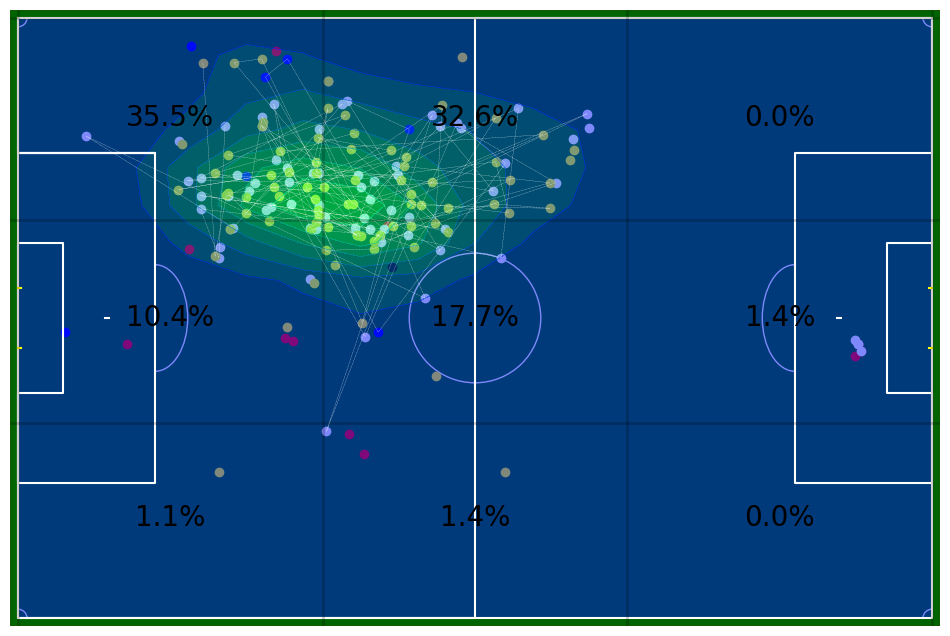

array([35.5, 32.6,  0. , 10.4, 17.7,  1.4,  1.1,  1.4,  0. ])

In [98]:
from scipy.stats.kde import gaussian_kde
match_id = 3890411
player_name = "John Anthony Brooks"

player_heatmap(match_id,player_name)

In [106]:
match_to_str = str(match_id)
event_path = os.path.join(events_path, match_to_str + '.json')
event_dict_list = json.load(open(event_path, 'r'))

event_dict_list[0]

{'id': 'ec5e3c08-1265-4ea6-b4b9-db30eb409da4',
 'index': 1,
 'period': 1,
 'timestamp': '00:00:00.000',
 'minute': 0,
 'second': 0,
 'type': {'id': 35, 'name': 'Starting XI'},
 'possession': 1,
 'possession_team': {'id': 173, 'name': 'Hertha Berlin'},
 'play_pattern': {'id': 1, 'name': 'Regular Play'},
 'team': {'id': 173, 'name': 'Hertha Berlin'},
 'duration': 0.0,
 'tactics': {'formation': 4231,
  'lineup': [{'player': {'id': 8577, 'name': 'Rune Almenning Jarstein'},
    'position': {'id': 1, 'name': 'Goalkeeper'},
    'jersey_number': 22},
   {'player': {'id': 8576, 'name': 'Mitchell Weiser'},
    'position': {'id': 2, 'name': 'Right Back'},
    'jersey_number': 20},
   {'player': {'id': 8580, 'name': 'Sebastian Langkamp'},
    'position': {'id': 3, 'name': 'Right Center Back'},
    'jersey_number': 15},
   {'player': {'id': 12327, 'name': 'John Anthony Brooks'},
    'position': {'id': 5, 'name': 'Left Center Back'},
    'jersey_number': 25},
   {'player': {'id': 5569, 'name': 'Marv

In [150]:
def match_composition(match_id):
    match_to_str = str(match_id)
    event_path = os.path.join(events_path, match_to_str + '.json')
    event_dict_list = json.load(open(event_path, 'r'))
    home_team = event_dict_list[0]["team"]["name"] 
    away_team = event_dict_list[1]["team"]["name"]

    players_in_home_team = [x["player"]["name"] for x in event_dict_list[0]["tactics"]["lineup"]]
    players_in_away_team = [x["player"]["name"] for x in event_dict_list[1]["tactics"]["lineup"]]
    
    home_players_weights = []
    away_players_weights = []
    home_total_duration = 0
    away_total_duration = 0

    for player in players_in_home_team:
        weights, duration = player_heatmap(match_id, player)
        home_players_weights.append(weights)
        home_total_duration += duration

    for player in players_in_away_team:
        weights, duration = player_heatmap(match_id, player)
        away_players_weights.append(weights)
        away_total_duration += duration
    
    home_team_weight = np.round(sum(home_players_weights)/home_total_duration*100, decimals=1)
    home_mat = home_team_weight.reshape(3,3)
    away_team_weight = np.round(sum(away_players_weights)/away_total_duration*100, decimals=1)
    away_mat = away_team_weight.reshape(3,3)
    max_val = max([home_mat.max(),away_mat.max()])
    title_size = 16
    fig, axes = plt.subplots(1,2)
    
    axes[0].set_title("Home_team", size=title_size)
    im = axes[0].imshow(home_mat, vmin =0, vmax = max_val)
    axes[1].set_title("Away_team", size=title_size)
    im = axes[1].imshow(away_mat, vmin =0, vmax = max_val)

    fig.colorbar(im, ax=axes.ravel().tolist())
    fig.suptitle("Match " +str(match_id) +" summary", size=title_size, y=0.93)
    
    plt.show()
    return home_mat,away_mat

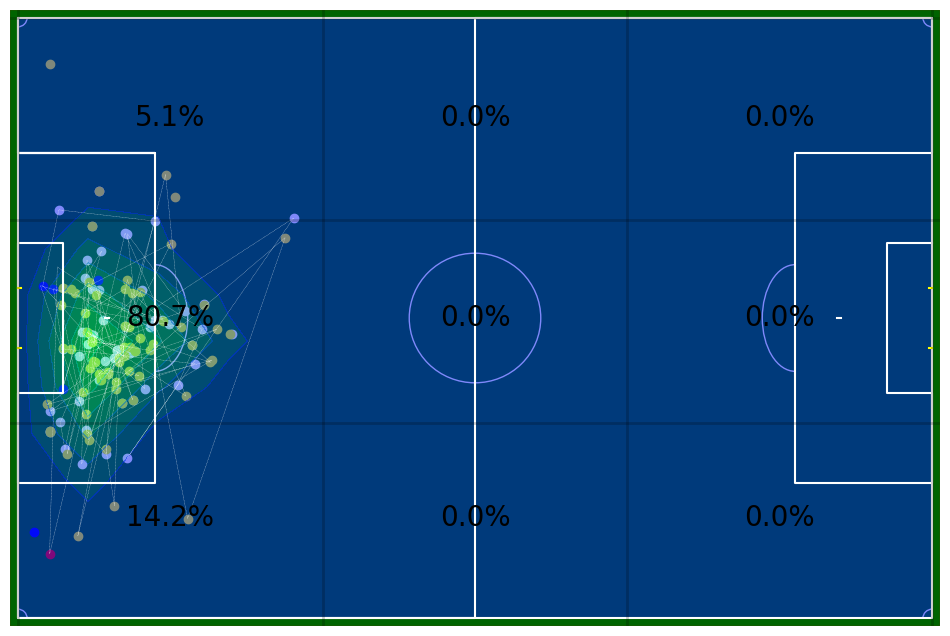

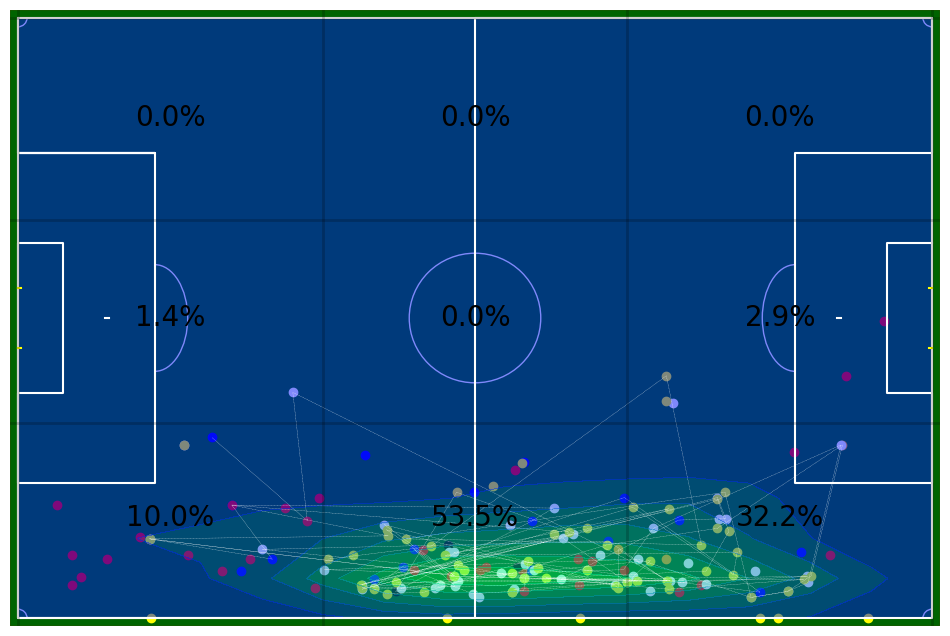

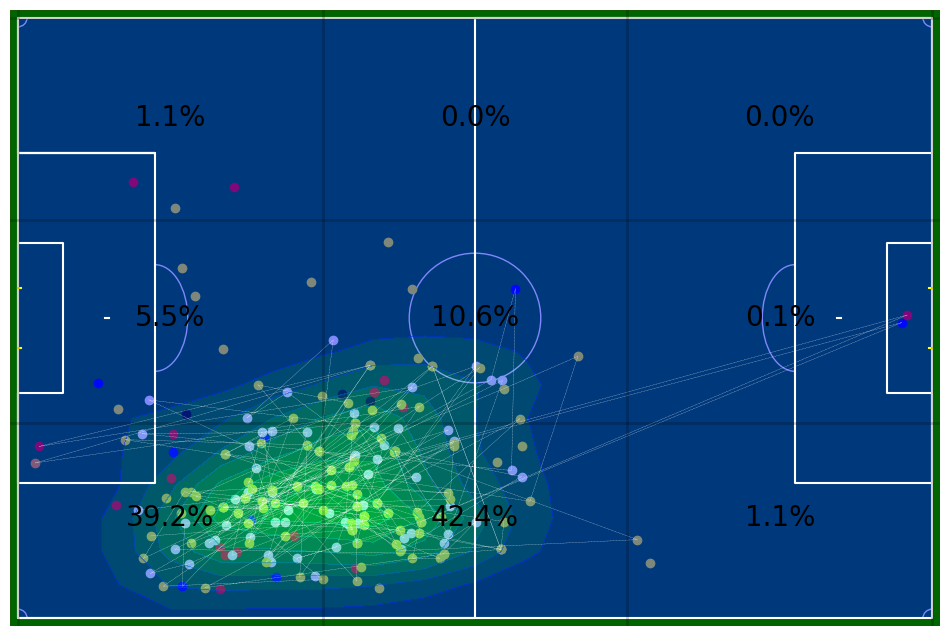

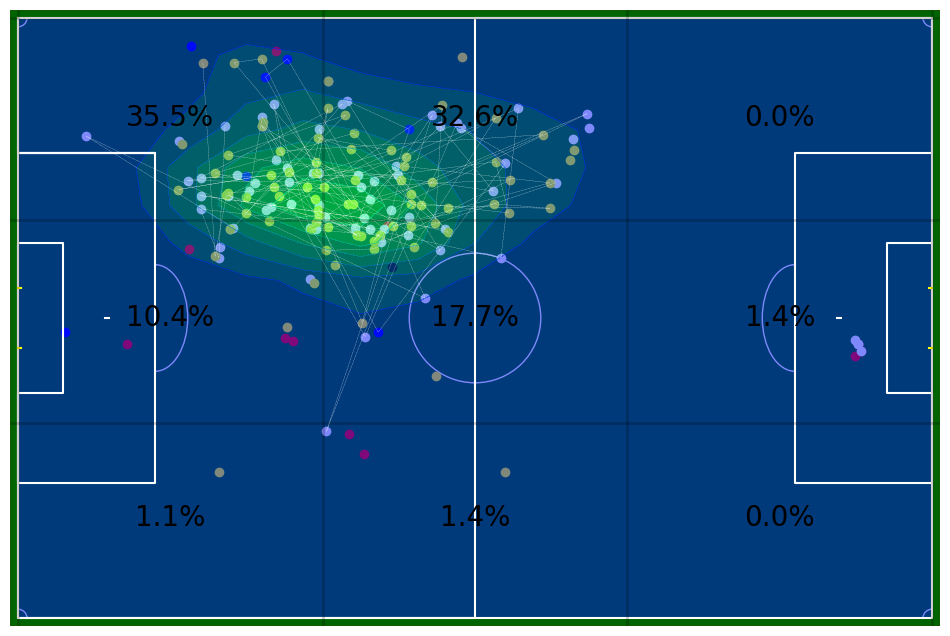

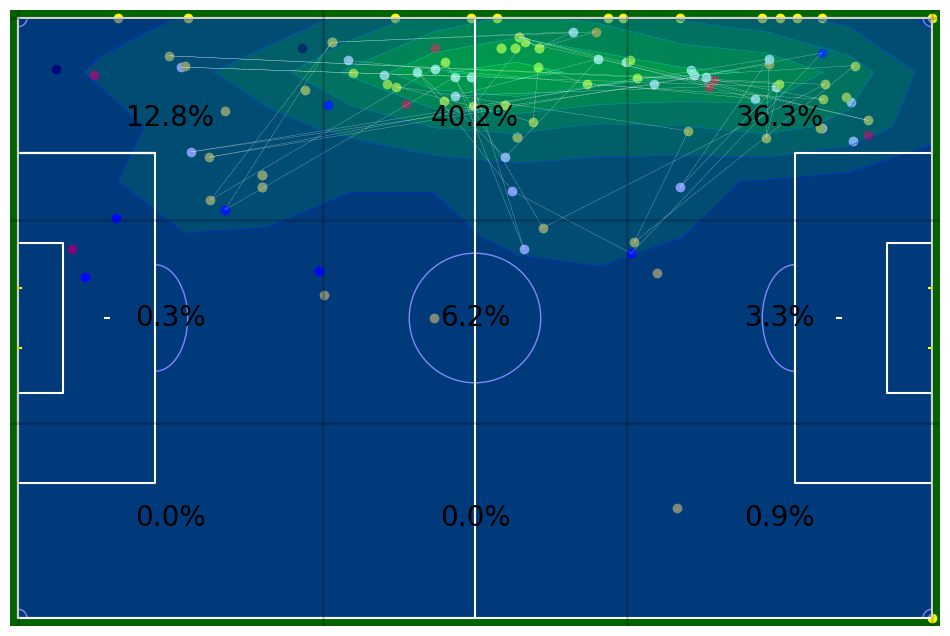

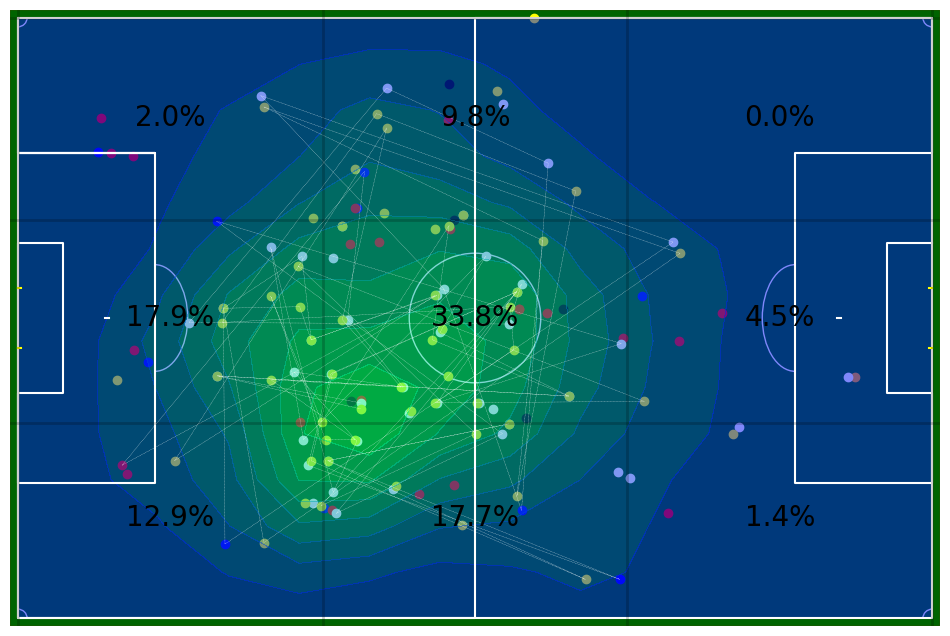

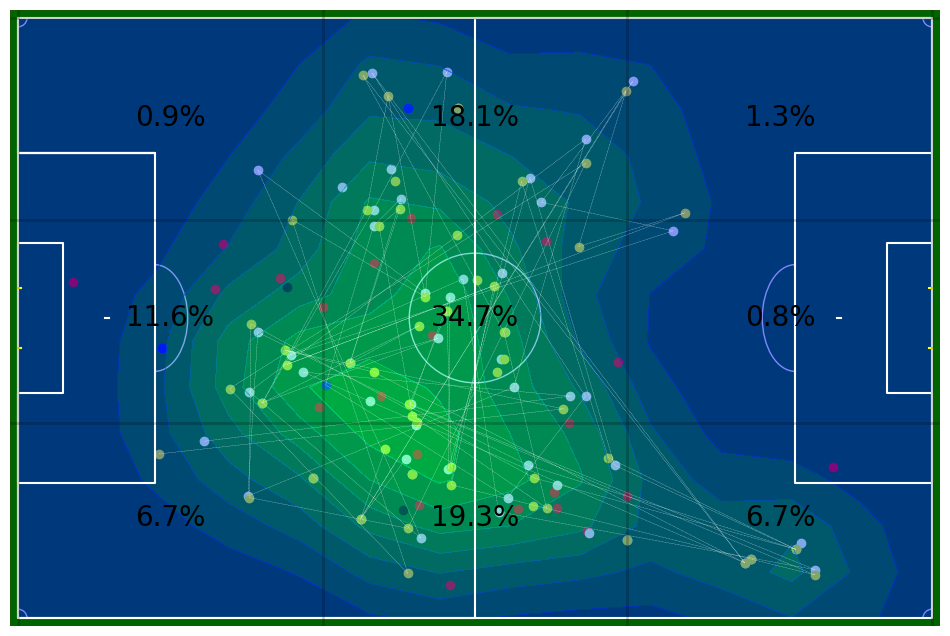

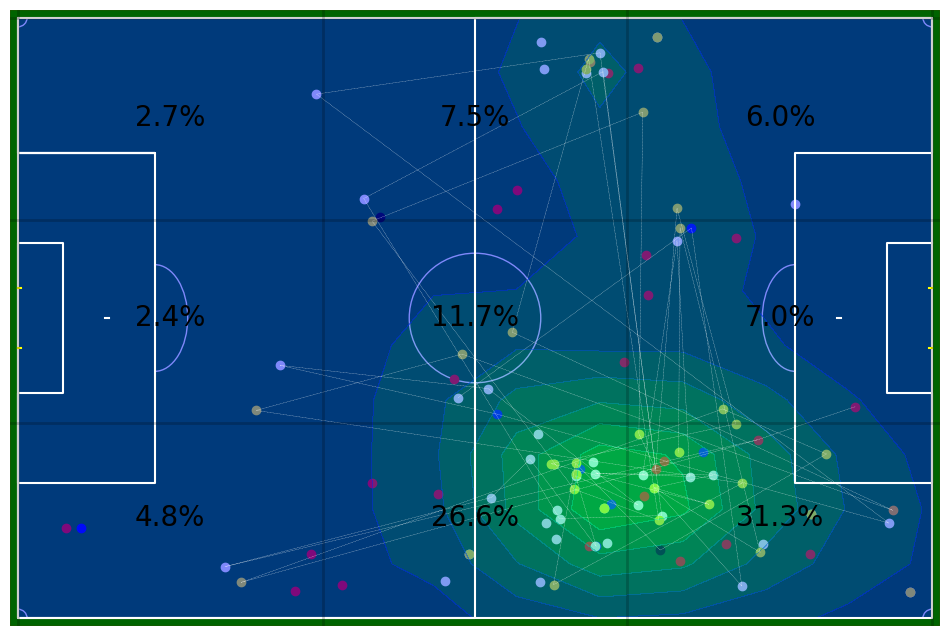

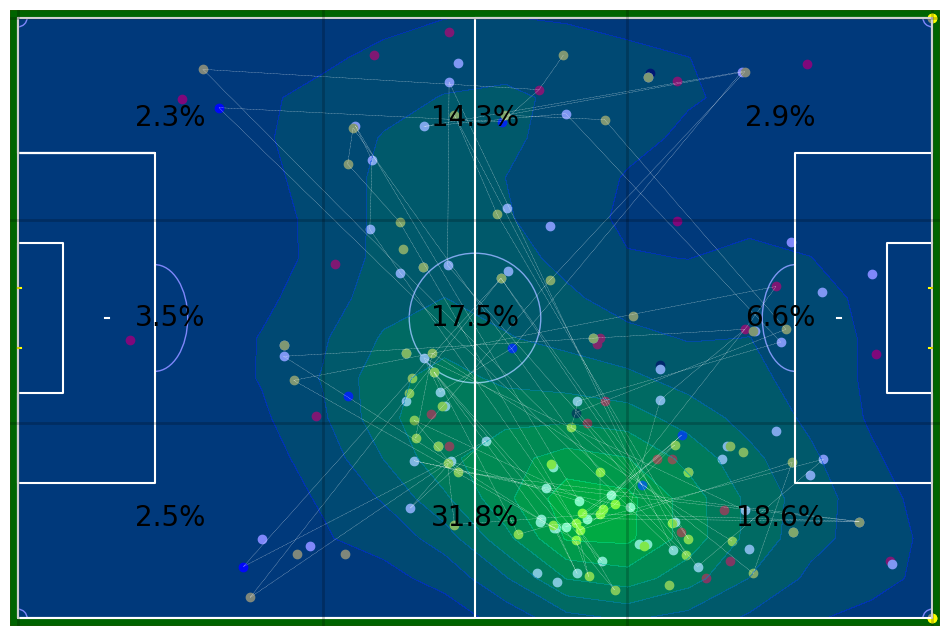

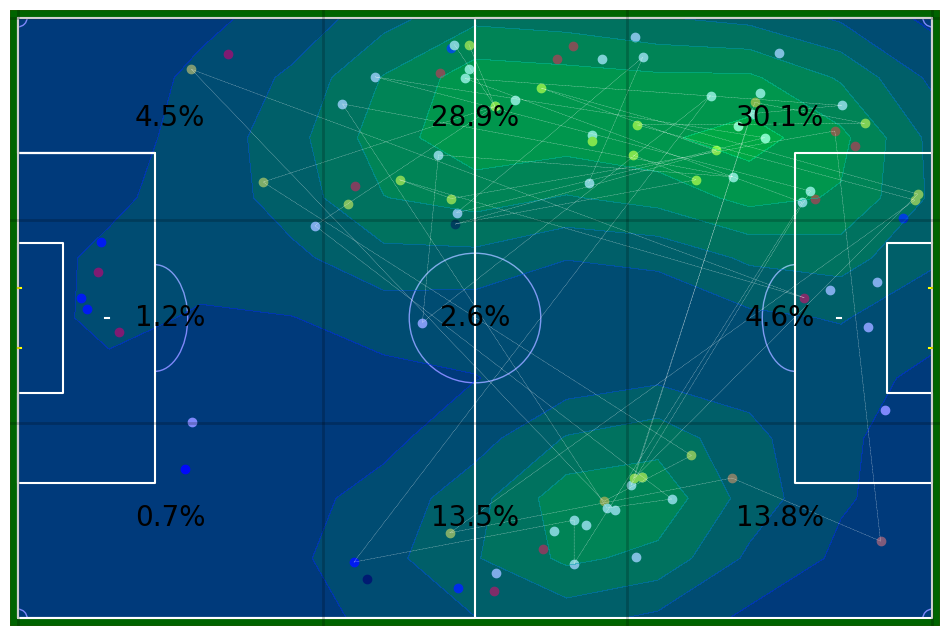

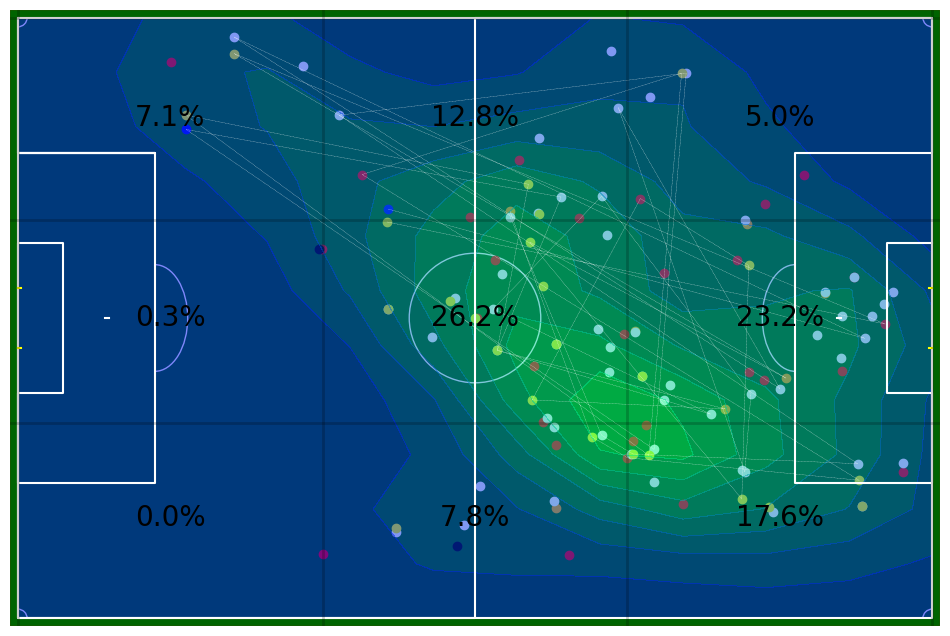

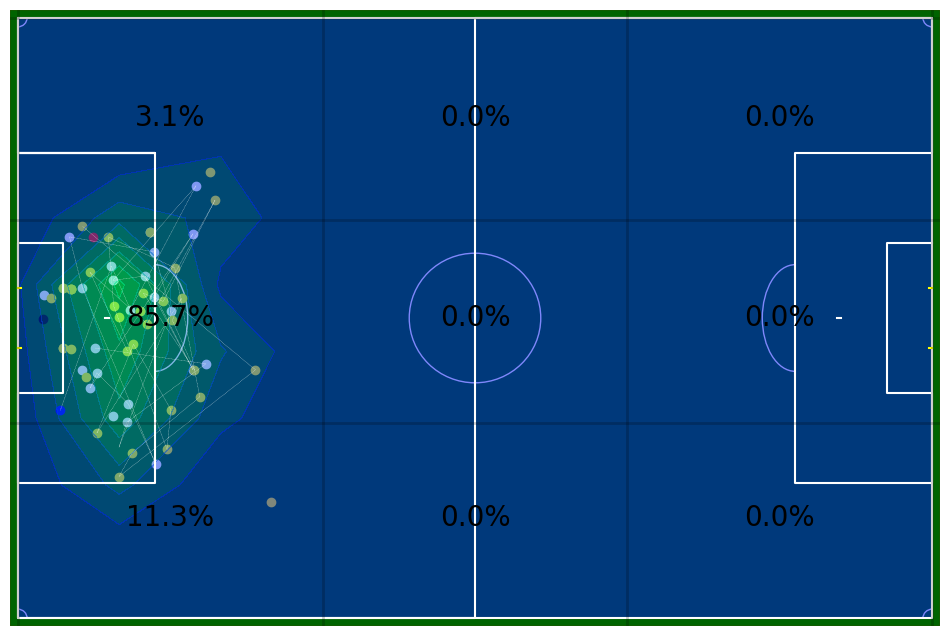

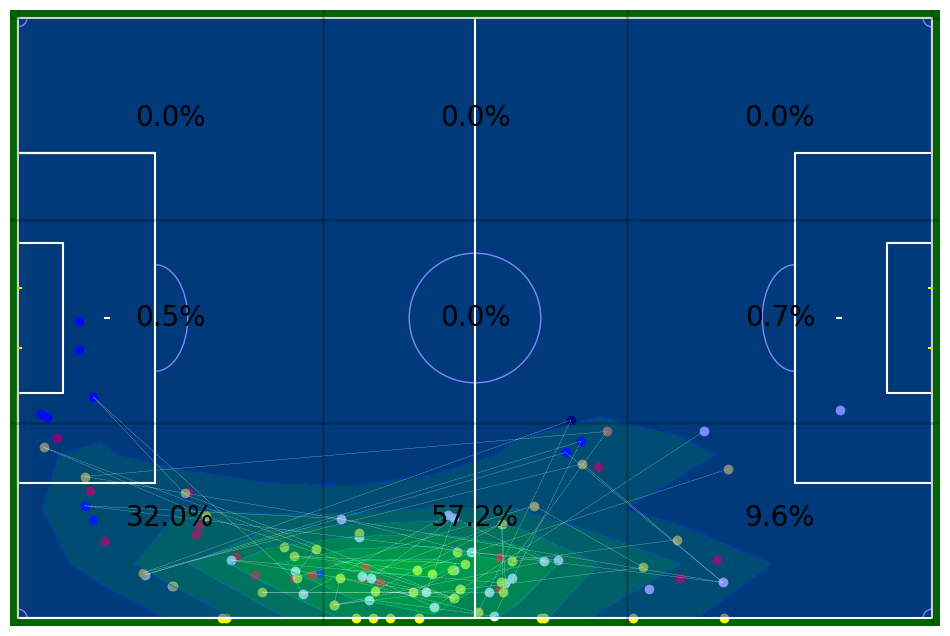

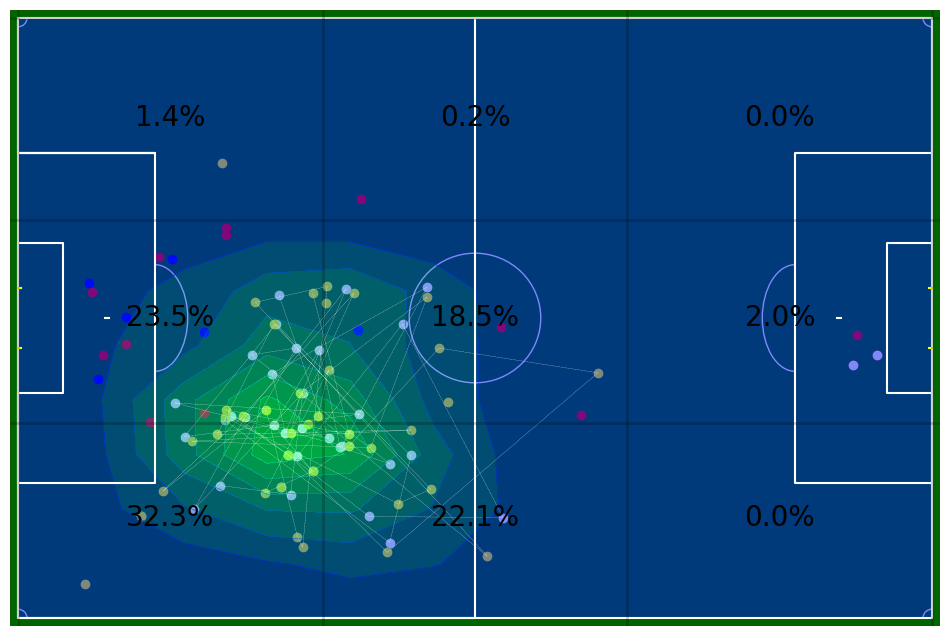

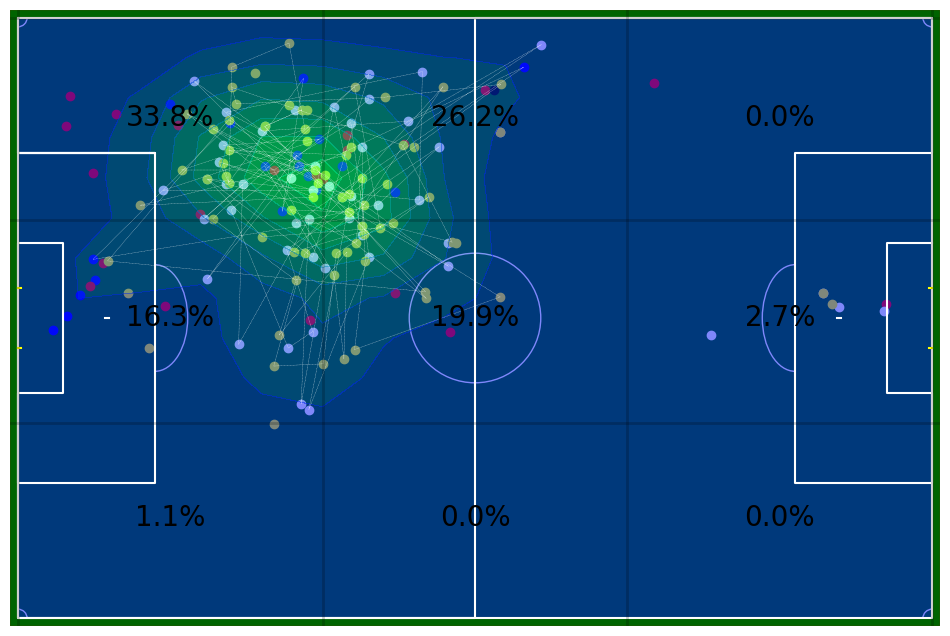

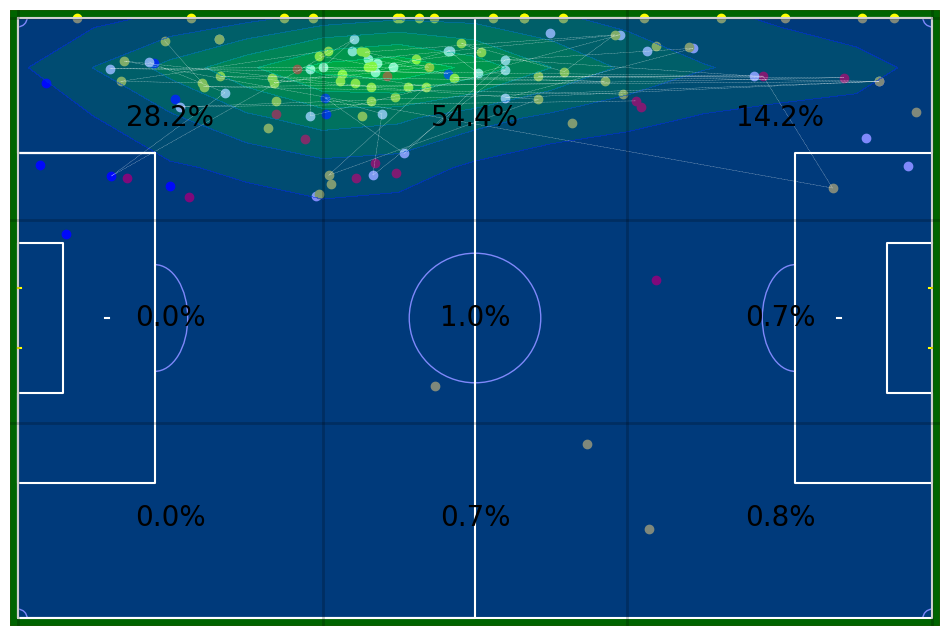

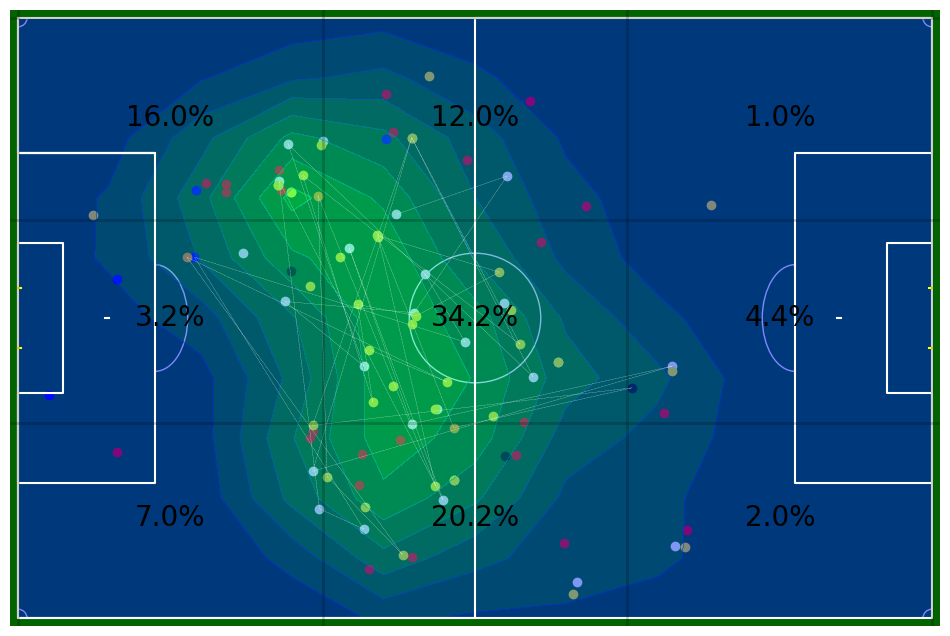

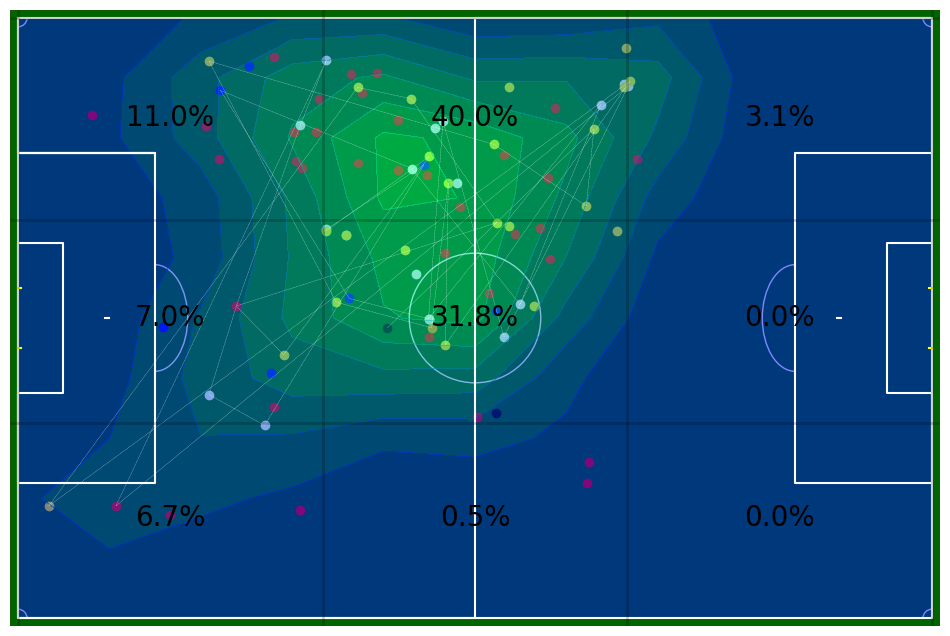

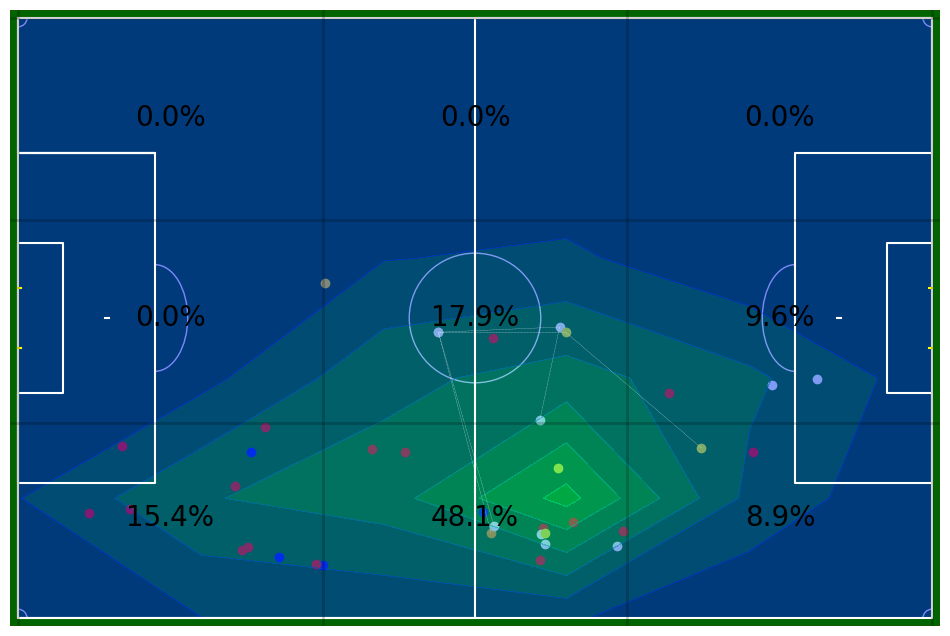

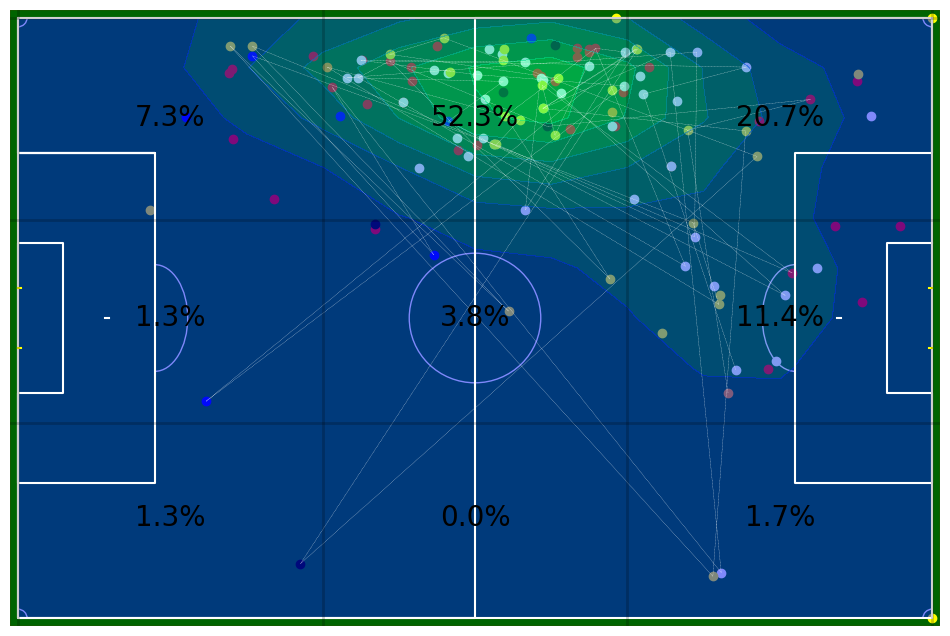

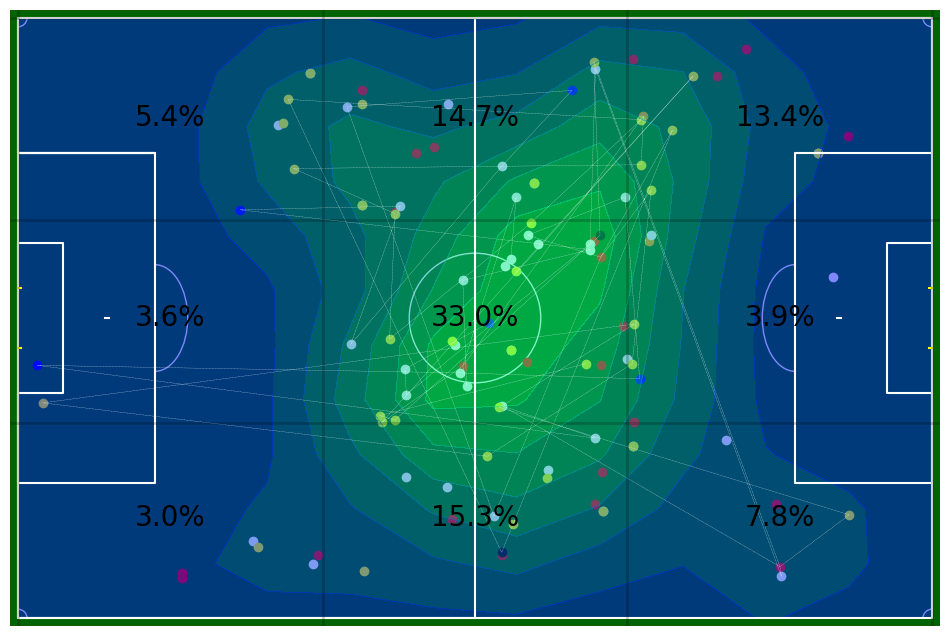

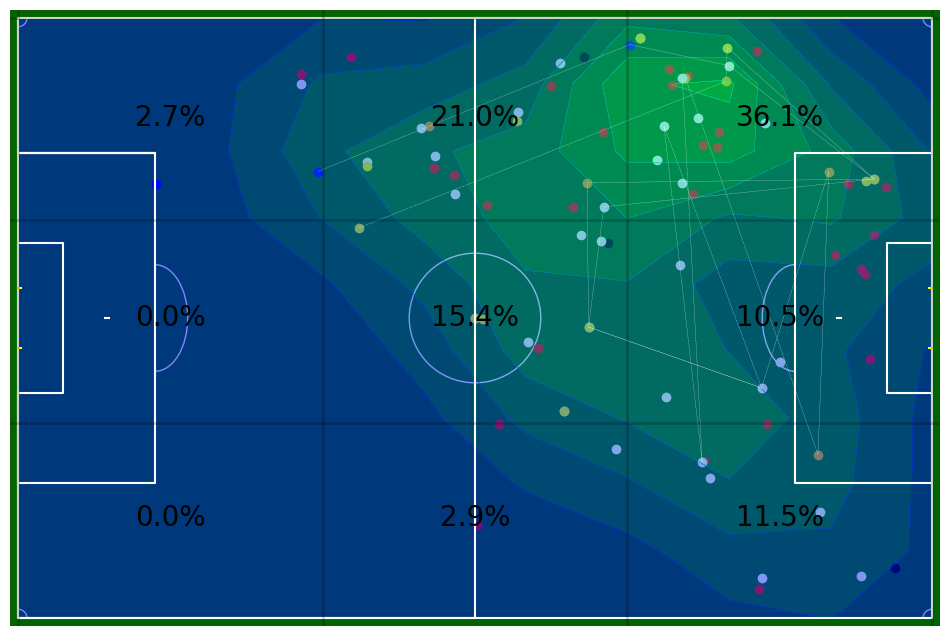

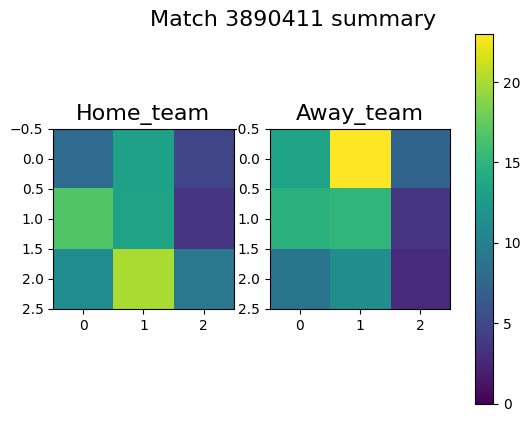

(array([[ 8. , 13.2,  4.8],
        [16.8, 13.3,  3.5],
        [11.2, 20.1,  9.1]]),
 array([[13.3, 23. ,  7.4],
        [14.8, 15.1,  3.5],
        [ 8.9, 11.3,  2.8]]))

In [151]:
match_id = 3890411
match_composition(match_id)